## Importy

W tej sekcji importujemy biblioteki potrzebne do pracy z danymi (pandas/numpy), wykresami świecowymi (mplfinance) oraz interaktywnym UI (ipywidgets).

In [638]:
# Opis: Import bibliotek używanych w notebooku.

import os
import datetime
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf
import talib
import scipy

import ipywidgets as widgets
from IPython.display import display, clear_output

from tqdm.notebook import tqdm

In [639]:
from talib._ta_lib import (
    _ta_set_candle_settings as set_candle_settings,
    _ta_restore_candle_default_settings as restore_candle_default_settings,
    CandleSettingType,
    RangeType
)

In [640]:
# Opis: Ustawienia ostrzeżeń oraz opcji wyświetlania (pandas/mplfinance).

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

warnings.filterwarnings("ignore", category=UserWarning, module="mplfinance")

In [641]:
from IPython.display import display, HTML

display(HTML("""
<style>
    body {
        overflow-x: hidden;
    }
    .jp-Notebook {
        overflow-x: hidden;
    }
</style>
"""))


# listy symboli

In [642]:
# Opis: Definicja listy symboli (tickery) do analizy.

SYMBOLS_500 = [
 'MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ARES',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AVB',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BBY',
 'TECH',
 'BIIB',
 'BX',
 'XYZ',
 'BK',
 'BA',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BLDR',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'CPB',
 'COF',
 'CAH',
 'CCL',
 'CARR',
 'CVNA',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COIN',
 'CL',
 'CMCSA',
 'FIX',
 'CAG',
 'COP',
 'ED',
 'STZ',
 'CEG',
 'COO',
 'CPRT',
 'GLW',
 'CPAY',
 'CTVA',
 'CSGP',
 'CTRA',
 'CRH',
 'CRWD',
 'CCI',
 'CSX',
 'CMI',
 'CVS',
 'DHR',
 'DRI',
 'DDOG',
 'DVA',
 'DAY',
 'DECK',
 'DE',
 'DELL',
 'DAL',
 'DVN',
 'DXCM',
 'FANG',
 'DLR',
 'DG',
 'DLTR',
 'D',
 'DPZ',
 'DASH',
 'DOV',
 'DOW',
 'DHI',
 'DTE',
 'DUK',
 'DD',
 'ETN',
 'EBAY',
 'ECL',
 'EIX',
 'EW',
 'EA',
 'ELV',
 'EME',
 'EMR',
 'ETR',
 'EOG',
 'EPAM',
 'EQT',
 'EFX',
 'EQR',
 'ERIE',
 'ESS',
 'EL',
 'EG',
 'EVRG',
 'ES',
 'EXC',
 'EXE',
 'EXPE',
 'EXPD',
 'EXR',
 'XOM',
 'FFIV',
 'FDS',
 'FAST',
 'FRT',
 'FDX',
 'FIS',
 'FITB',
 'FSLR',
 'FE',
 'FISV',
 'F',
 'FTNT',
 'FTV',
 'FOXA',
 'FOX',
 'BEN',
 'FCX',
 'GRMN',
 'IT',
 'GE',
 'GEHC',
 'GEV',
 'GEN',
 'GNRC',
 'GD',
 'GIS',
 'GM',
 'GPC',
 'GILD',
 'GPN',
 'GL',
 'GDDY',
 'GS',
 'HAL',
 'HIG',
 'HAS',
 'HCA',
 'DOC',
 'HSIC',
 'HSY',
 'HPE',
 'HLT',
 'HOLX',
 'HD',
 'HON',
 'HRL',
 'HST',
 'HWM',
 'HPQ',
 'HUBB',
 'HUM',
 'HBAN',
 'HII',
 'IBM',
 'IEX',
 'ITW',
 'INCY',
 'IR',
 'PODD',
 'INTC',
 'IBKR',
 'ICE',
 'IFF',
 'IP',
 'ISRG',
 'IVZ',
 'INVH',
 'IQV',
 'IRM',
 'JBHT',
 'JBL',
 'JKHY',
 'J',
 'JNJ',
 'JCI',
 'JPM',
 'KVUE',
 'KDP',
 'KEY',
 'KEYS',
 'KMB',
 'KIM',
 'KMI',
 'KKR',
 'KHC',
 'KR',
 'LHX',
 'LH',
 'LRCX',
 'LW',
 'LVS',
 'LDOS',
 'LEN',
 'LII',
 'LIN',
 'LYV',
 'LMT',
 'L',
 'LOW',
 'LULU',
 'LYB',
 'MTB',
 'MPC',
 'MAR',
 'MMC',
 'MLM',
 'MAS',
 'MA',
 'MTCH',
 'MKC',
 'MCD',
 'MCK',
 'MDT',
 'MRK',
 'META',
 'MET',
 'MGM',
 'MCHP',
 'MU',
 'MSFT',
 'MAA',
 'MRNA',
 'MOH',
 'TAP',
 'MDLZ',
 'MNST',
 'MCO',
 'MS',
 'MOS',
 'MSI',
 'NDAQ',
 'NTAP',
 'NFLX',
 'NEM',
 'NWSA',
 'NWS',
 'NEE',
 'NKE',
 'NI',
 'NDSN',
 'NSC',
 'NTRS',
 'NOC',
 'NCLH',
 'NRG',
 'NUE',
 'NVDA',
 'NXPI',
 'ORLY',
 'OXY',
 'ODFL',
 'OMC',
 'ON',
 'OKE',
 'ORCL',
 'OTIS',
 'PCAR',
 'PKG',
 'PLTR',
 'PANW',
 'PSKY',
 'PH',
 'PAYX',
 'PAYC',
 'PYPL',
 'PNR',
 'PEP',
 'PFE',
 'PCG',
 'PM',
 'PSX',
 'PNW',
 'PNC',
 'POOL',
 'PPG',
 'PPL',
 'PFG',
 'PG',
 'PGR',
 'PLD',
 'PRU',
 'PEG',
 'PTC',
 'PSA',
 'PHM',
 'PWR',
 'QCOM',
 'DGX',
 'Q',
 'RL',
 'RJF',
 'RTX',
 'O',
 'REG',
 'RF',
 'RSG',
 'RMD',
 'RVTY',
 'HOOD',
 'ROK',
 'ROL',
 'ROST',
 'RCL',
 'SPGI',
 'CRM',
 'SNDK',
 'SBAC',
 'SLB',
 'STX',
 'SRE',
 'NOW',
 'SHW',
 'SPG',
 'SWKS',
 'SJM',
 'SW',
 'SNA',
 'SOLV',
 'SO',
 'LUV',
 'SWK',
 'SBUX',
 'STT',
 'STLD',
 'STE',
 'SYK',
 'SMCI',
 'SYF',
 'SNPS',
 'SYY',
 'TMUS',
 'TROW',
 'TTWO',
 'TPR',
 'TRGP',
 'TGT',
 'TEL',
 'TDY',
 'TER',
 'TSLA',
 'TXN',
 'TPL',
 'TXT',
 'TJX',
 'TKO',
 'TTD',
 'TSCO',
 'TT',
 'TRV',
 'TRMB',
 'TFC',
 'TYL',
 'TSN',
 'USB',
 'UBER',
 'UDR',
 'ULTA',
 'UNP',
 'UAL',
 'UPS',
 'UHS',
 'VLO',
 'VTR',
 'VLTO',
 'VRSN',
 'VRSK',
 'VZ',
 'VRTX',
 'VTRS',
 'VICI',
 'V',
 'VST',
 'VMC',
 'WRB',
 'WAB',
 'WMT',
 'DIS',
 'WBD',
 'WM',
 'WAT',
 'WEC',
 'WFC',
 'WELL',
 'WST',
 'WDC',
 'WY',
 'WSM',
 'WMB',
 'WTW',
 'WDAY',
 'WYNN',
 'XEL',
 'XYL',
 'YUM',
 'ZBRA',
 'ZBH',
 'ZTS']

In [643]:
CRYPTO_TOP_50 = [
    "BTC-USD",   # Bitcoin
    "ETH-USD",   # Ethereum
    "USDT-USD",  # Tether
    "BNB-USD",   # Binance Coin
    "SOL-USD",   # Solana
    "USDC-USD",  # USD Coin
    "XRP-USD",   # XRP
    "TON11419-USD",  # Toncoin (Yahoo uses this weird symbol)
    "DOGE-USD",  # Dogecoin
    "ADA-USD",   # Cardano
    "AVAX-USD",  # Avalanche
    "SHIB-USD",  # Shiba Inu
    "TRX-USD",   # TRON
    "DOT-USD",   # Polkadot
    "LINK-USD",  # Chainlink
    "MATIC-USD", # Polygon
    "BCH-USD",   # Bitcoin Cash
    "ICP-USD",   # Internet Computer
    "LTC-USD",   # Litecoin
    "UNI7083-USD", # Uniswap (Yahoo-specific code)
    "ATOM-USD",  # Cosmos
    "ETC-USD",   # Ethereum Classic
    "XLM-USD",   # Stellar
    "FIL-USD",   # Filecoin
    "APT-USD",   # Aptos
    "HBAR-USD",  # Hedera
    "NEAR-USD",  # Near Protocol
    "OP-USD",    # Optimism
    #"IMX-USD",   # Immutable
    "INJ-USD",   # Injective
    "ARB-USD",   # Arbitrum
    "RNDR-USD",  # Render
    #"GRT-USD",   # The Graph
    "AAVE-USD",  # Aave
    "FLOW-USD",  # Flow
    "MKR-USD",   # Maker
    "SAND-USD",  # The Sandbox
    "THETA-USD", # Theta
    "KAS-USD",   # Kaspa
    "EGLD-USD",  # MultiversX
    "AXS-USD",   # Axie Infinity
    "XTZ-USD",   # Tezos
    "NEO-USD",   # Neo
    "MINA-USD",  # Mina
    "SNX-USD",   # Synthetix
    "CRV-USD",   # Curve
    "CHZ-USD",   # Chiliz
    "DYDX-USD",  # dYdX
]


In [644]:
COMMODITY_SYMBOLS = [

    # =========================
    # 🥇 PRECIOUS METALS
    # =========================
    "GC=F",    # Gold
    "SI=F",    # Silver
    "PL=F",    # Platinum
    "PA=F",    # Palladium

    # =========================
    # 🏗 INDUSTRIAL / BASE METALS
    # =========================
    "HG=F",    # Copper
    "ALI=F",   # Aluminum (unstable)
    "ZNC=F",   # Zinc (unstable)
    "NICKEL=F",# Nickel (very unstable)
    "TIN=F",   # Tin (rarely works)

    # =========================
    # 🛢 ENERGY
    # =========================
    "CL=F",    # Crude Oil WTI
    "BZ=F",    # Brent Crude
    "NG=F",    # Natural Gas
    "HO=F",    # Heating Oil
    "RB=F",    # Gasoline RBOB
    "MGC=F",   # Micro Gold
    "QG=F",    # Mini Natural Gas

    # =========================
    # 🌾 GRAINS
    # =========================
    "ZC=F",    # Corn
    "ZW=F",    # Wheat
    "ZS=F",    # Soybeans
    "ZM=F",    # Soybean Meal
    "ZL=F",    # Soybean Oil
    "ZR=F",    # Rough Rice
    "ZO=F",    # Oats

    # =========================
    # ☕ SOFT COMMODITIES
    # =========================
    "KC=F",    # Coffee
    "SB=F",    # Sugar
    "CT=F",    # Cotton
    "CC=F",    # Cocoa
    "OJ=F",    # Orange Juice
    "LB=F",    # Lumber

    # =========================
    # 🐄 LIVESTOCK
    # =========================
    "LE=F",    # Live Cattle
    "GF=F",    # Feeder Cattle
    "HE=F",    # Lean Hogs

    # =========================
    # 🧪 CHEMICALS / FERTILIZERS (SPOTTY)
    # =========================
    "UREA=F",  # Urea (often empty)
    "DAPHOS=F",# DAP Fertilizer (rare)

    # =========================
    # 🌍 MACRO / COMMODITY INDICES
    # =========================
    "^BCOM",   # Bloomberg Commodity Index
    "^CRB",    # CRB Index

    # =========================
    # 📦 COMMODITY ETF PROXIES (VERY RELIABLE)
    # =========================
    "GLD",     # Gold ETF
    "SLV",     # Silver ETF
    "USO",     # Oil ETF
    "UNG",     # Natural Gas ETF
    "DBC",     # Broad commodities
    "DBA",     # Agriculture basket
    "DBB",     # Base metals basket
    "WOOD",    # Timber
    "CORN",    # Corn ETF
    "WEAT",    # Wheat ETF
    "SOYB",    # Soybeans ETF

]


# poczatkowy config

In [645]:
import json
import os

SETTINGS_PATH = "global_settings.json"


In [646]:
file_path_widget = widgets.Text(
    value="",
    placeholder="/path/to/data.csv",
    description="File path:",
    layout=widgets.Layout(width="600px")
)

market_widget = widgets.ToggleButtons(
    options=[
        ("Krypto", "crypto"),
        ("Spółki", "stocks"),
        ("Surowce", "commodities"),
    ],
    description="Market:",
    button_style=""
)


interval_widget = widgets.ToggleButtons(
    options=[
        #("1 min", "1m"),
        #("5 min", "5m"),
        #("15 min", "15m"),
        ("4 hour", "4h"),
        ("1 day", "1d"),
        ("1 week", "1week"),
    ],
    #value="1d",
    description="Interval:"
)

week_start_widget = widgets.Dropdown(
    options=[
        ("BASE (no shift)", "BASE"),
        ("Monday", "MON"),
        ("Tuesday", "TUE"),
        ("Wednesday", "WED"),
        ("Thursday", "THU"),
        ("Friday", "FRI"),
    ],
    value="BASE",
    description="Week start(works only in 1d interval (converts it to weekly)):",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px"),
)


upload_widget = widgets.FileUpload(
    accept=".csv",
    multiple=False
)

uploaded = upload_widget.value

save_button = widgets.Button(
    description="Save settings",
    button_style="success",
    icon="save"
)

status_out = widgets.Output()


if uploaded:
    file_info = uploaded[0]        # first (and only) file
    content = file_info["content"] # bytes
    filename = file_info["name"]

### volume filter widgets ###

vol_ratio_window_widget = widgets.IntSlider(
    value=20,
    min=5,
    max=50,
    step=1,
    description="Vol window:",
    continuous_update=False,
    style={"description_width": "120px"},
)

vol_ratio_threshold_widget = widgets.FloatSlider(
    value=1.5,
    min=0.1,
    max=2.0,
    step=0.1,
    description="Vol threshold:",
    continuous_update=False,
    style={"description_width": "120px"},
)

vol_enabled_widget = widgets.Checkbox(
    value=True,
    description="Use volume filter",
    indent=False
)

### cmo filter widgets ###

cmo_thres_widget = widgets.IntSlider(
    value=20,
    min=-100,
    max=100,
    step=5,
    description="Cmo thres (current candle):",
    continuous_update=False,
    style={"description_width": "120px"},
)

cmo_thres_prev_widget = widgets.IntSlider(
    value=20,
    min=-100,
    max=100,
    step=5,
    description="Cmo thres (previous candle):",
    continuous_update=False,
    style={"description_width": "120px"},
)

cmo_enabled_widget = widgets.Checkbox(
    value=True,
    description="Use cmo filter",
    indent=False
)

def save_settings(_):
    settings = {
        "market": market_widget.value,
        "interval": interval_widget.value,
        'week_start': week_start_widget.value,

        # ---- volume params ----
        "vol_enabled": vol_enabled_widget.value,
        "vol_ratio_window": vol_ratio_window_widget.value,
        "vol_ratio_threshold": vol_ratio_threshold_widget.value,

        # ---- cmo params ----
        "cmo_enabled": cmo_enabled_widget.value,
        "cmo_thres": cmo_thres_widget.value,
        "cmo_thres_prev": cmo_thres_prev_widget.value,
    }

    with open(SETTINGS_PATH, "w") as f:
        json.dump(settings, f, indent=2)

    with status_out:
        status_out.clear_output()
        #print("✅ Settings saved")



save_button.on_click(save_settings)


def load_settings():
    if not os.path.exists(SETTINGS_PATH):
        return

    with open(SETTINGS_PATH, "r") as f:
        settings = json.load(f)

    # ---- market & interval ----
    if "market" in settings:
        market_widget.value = settings["market"]

    if "interval" in settings:
        interval_widget.value = settings["interval"]

    if "week_start" in settings:
        week_start_widget.value = settings["week_start"]
        
    # ---- volume params ----
    if "vol_enabled" in settings:
        vol_enabled_widget.value = settings["vol_enabled"]

    if "vol_ratio_window" in settings:
        vol_ratio_window_widget.value = settings["vol_ratio_window"]

    if "vol_ratio_threshold" in settings:
        vol_ratio_threshold_widget.value = settings["vol_ratio_threshold"]

    # ---- cmo params ----
    if "cmo_enabled" in settings:
        cmo_enabled_widget.value = settings["cmo_enabled"]

    if "cmo_thres" in settings:
        cmo_thres_widget.value = settings["cmo_thres"]

    if "cmo_thres_prev" in settings:
        cmo_thres_prev_widget.value = settings["cmo_thres_prev"]


load_settings()

def get_widget_values():
    file_path = file_path_widget.value
    interval = interval_widget.value
    #exit_candles = interval_n_widget.value

    return file_path, interval


In [647]:
PANEL_WIDTH = "1000px"

MAIN_BOX = widgets.Layout(
    width=PANEL_WIDTH,
    padding="16px",
    margin="8px 0",
    border="1px solid #ddd",
    align_items="flex-start"
)

SECTION_BOX = widgets.Layout(
    width="95%",
    padding="12px",
    margin="12px 0",
    border="1px solid #eee",
)

ROW_GRID = widgets.Layout(
    width="100%",
    display="grid",
    grid_template_columns="220px 1fr 1fr",
    align_items="center",
    gap="12px",
)

CHECKBOX_COL = widgets.Layout(
    width="220px",
    align_self="center"
)


In [648]:
CHECKBOX_COL = widgets.Layout(width="220px")
SLIDER_COL = widgets.Layout(width="95%")

# volume
vol_enabled_widget.layout = CHECKBOX_COL
vol_ratio_window_widget.layout = SLIDER_COL
vol_ratio_threshold_widget.layout = SLIDER_COL

# cmo
cmo_enabled_widget.layout = CHECKBOX_COL
cmo_thres_widget.layout = SLIDER_COL
cmo_thres_prev_widget.layout = SLIDER_COL


In [649]:
area_panel = widgets.VBox(
    [
        widgets.HTML("<h3>Area picking</h3>"),
        widgets.HBox(
            [market_widget, interval_widget],
            layout=widgets.Layout(
                display="flex",
                gap="12px",
                flex_flow="row wrap",
                align_items="center"
            )
        ),
    ]
)

volume_panel = widgets.VBox(
    [
        widgets.HTML("<h3>Volume Filter Settings</h3>"),
        widgets.Box(
            [
                vol_enabled_widget,
                vol_ratio_window_widget,
                vol_ratio_threshold_widget,
            ],
            layout=ROW_GRID
        ),
    ],
    layout=SECTION_BOX
)

cmo_panel = widgets.VBox(
    [
        widgets.HTML("<h3>CMO Filter Settings</h3>"),
        widgets.Box(
            [
                cmo_enabled_widget,
                cmo_thres_widget,
                cmo_thres_prev_widget,
            ],
            layout=ROW_GRID
        ),
    ],
    layout=SECTION_BOX
)



save_button.layout = widgets.Layout(width="260px", height="48px")

save_row = widgets.HBox(
    [save_button],
    layout=widgets.Layout(
        width="100%",
        justify_content="center",
        margin="12px 0"
    )
)


In [650]:
settings_panel = widgets.VBox(
    [
        area_panel,
        status_out,
        widgets.HTML("<hr>"),
        week_start_widget,
        widgets.HTML("<hr>"),
        volume_panel,
        cmo_panel,
        widgets.HTML("<hr>"),
        save_row,
    ],
    layout=MAIN_BOX
)

## guziczki

In [651]:
display(settings_panel)


In [652]:
def get_params():
    return {
        "market": market_widget.value,
        "interval": interval_widget.value,
        'week_start': week_start_widget.value,

        "vol_enabled": vol_enabled_widget.value,
        "vol_ratio_window": vol_ratio_window_widget.value,
        "vol_ratio_threshold": vol_ratio_threshold_widget.value,

        "cmo_enabled": cmo_enabled_widget.value,
        "cmo_thres": cmo_thres_widget.value,
        "cmo_thres_prev": cmo_thres_prev_widget.value,
    }
settings = get_params()
print(settings)


{'market': 'stocks', 'interval': '1d', 'week_start': 'MON', 'vol_enabled': True, 'vol_ratio_window': 20, 'vol_ratio_threshold': 1.2000000000000002, 'cmo_enabled': True, 'cmo_thres': -35, 'cmo_thres_prev': -50}


In [653]:
import os

DATA_DIR = os.path.join(
    "all_data",
    f"data_{settings['market']}_{settings['interval']}"
)

SETTINGS_FILE = (
    "candle_settings_1week.json"
    if settings["interval"] == "1week"
    else "candle_settings_1d.json"
)


In [654]:
#DATA_DIR

In [655]:
SYMBOLS = SYMBOLS_500 if settings['market'] == 'stocks' else CRYPTO_TOP_50 if settings['market'] == 'crypto' else COMMODITY_SYMBOLS

# parametry talib

## techniczne

### deafulty

In [656]:
DEFAULT_PARAMS = {

    # ==========================================================================
    # SINGLE CANDLE PATTERNS
    # ==========================================================================

    # --- HAMMER ---
    "HAMMER_BODY_SHORT_LB": 10,
    "HAMMER_BODY_SHORT": 1.0,
    "HAMMER_SHADOW_LONG_LB": 0,
    "HAMMER_SHADOW_LONG": 1.0,
    "HAMMER_SHADOW_VERY_SHORT_LB": 10,
    "HAMMER_SHADOW_VERY_SHORT": 0.1,
    "HAMMER_NEAR_LB": 5,
    "HAMMER_NEAR": 0.2,

    # --- INVERTED HAMMER ---
    "INVERTED_HAMMER_BODY_SHORT_LB": 10,
    "INVERTED_HAMMER_BODY_SHORT": 1.0,
    "INVERTED_HAMMER_SHADOW_LONG_LB": 0,
    "INVERTED_HAMMER_SHADOW_LONG": 1.0,
    "INVERTED_HAMMER_SHADOW_VERY_SHORT_LB": 10,
    "INVERTED_HAMMER_SHADOW_VERY_SHORT": 0.1,

    # --- SHOOTING STAR ---
    "SHOOTING_STAR_BODY_SHORT_LB": 10,
    "SHOOTING_STAR_BODY_SHORT": 1.0,
    "SHOOTING_STAR_SHADOW_LONG_LB": 0,
    "SHOOTING_STAR_SHADOW_LONG": 1.0,
    "SHOOTING_STAR_SHADOW_VERY_SHORT_LB": 10,
    "SHOOTING_STAR_SHADOW_VERY_SHORT": 0.1,

    # --- HANGING MAN ---
    "HANGING_MAN_BODY_SHORT_LB": 10,
    "HANGING_MAN_BODY_SHORT": 1.0,
    "HANGING_MAN_SHADOW_LONG_LB": 0,
    "HANGING_MAN_SHADOW_LONG": 1.0,
    "HANGING_MAN_SHADOW_VERY_SHORT_LB": 10,
    "HANGING_MAN_SHADOW_VERY_SHORT": 0.1,
    "HANGING_MAN_NEAR_LB": 5,
    "HANGING_MAN_NEAR": 0.2,

    # --- DOJI FAMILY ---
    "DOJI_BODY_LB": 10,
    "DOJI_BODY": 0.1,
    "LONG_LEGGED_DOJI_SHADOW_LONG_LB": 0,
    "LONG_LEGGED_DOJI_SHADOW_LONG": 1.0,
    "DRAGONFLY_DOJI_SHADOW_LONG_LB": 0,
    "DRAGONFLY_DOJI_SHADOW_LONG": 1.0,
    "DRAGONFLY_DOJI_SHADOW_VERY_SHORT_LB": 10,
    "DRAGONFLY_DOJI_SHADOW_VERY_SHORT": 0.1,
    "GRAVESTONE_DOJI_SHADOW_LONG_LB": 0,
    "GRAVESTONE_DOJI_SHADOW_LONG": 1.0,
    "GRAVESTONE_DOJI_SHADOW_VERY_SHORT_LB": 10,
    "GRAVESTONE_DOJI_SHADOW_VERY_SHORT": 0.1,

    # --- SPINNING TOP ---
    "SPINNING_TOP_BODY_SHORT_LB": 10,
    "SPINNING_TOP_BODY_SHORT": 1.0,

    # --- MARUBOZU ---
    "MARUBOZU_BODY_LONG_LB": 10,
    "MARUBOZU_BODY_LONG": 1.0,
    "MARUBOZU_SHADOW_VERY_SHORT_LB": 10,
    "MARUBOZU_SHADOW_VERY_SHORT": 0.1,

    # ==========================================================================
    # DOUBLE CANDLE PATTERNS
    # ==========================================================================

    "PIERCING_BODY_LONG_LB": 10,
    "PIERCING_BODY_LONG": 1.0,
    "DARK_CLOUD_BODY_LONG_LB": 10,
    "DARK_CLOUD_BODY_LONG": 1.0,

    # ==========================================================================
    # TRIPLE CANDLE PATTERNS
    # ==========================================================================

    "ABANDONED_BABY_BODY_LONG_LB": 10,
    "ABANDONED_BABY_BODY_LONG": 1.0,
    "ABANDONED_BABY_DOJI_LB": 10,
    "ABANDONED_BABY_DOJI": 0.1,

    "MORNING_STAR_BODY_LONG_LB": 10,
    "MORNING_STAR_BODY_LONG": 1.0,
    "MORNING_STAR_BODY_SHORT_LB": 10,
    "MORNING_STAR_BODY_SHORT": 1.0,

    "MORNING_DOJI_STAR_BODY_LONG_LB": 10,
    "MORNING_DOJI_STAR_BODY_LONG": 1.0,
    "MORNING_DOJI_STAR_DOJI_LB": 10,
    "MORNING_DOJI_STAR_DOJI": 0.1,

    "EVENING_STAR_BODY_LONG_LB": 10,
    "EVENING_STAR_BODY_LONG": 1.0,
    "EVENING_STAR_BODY_SHORT_LB": 10,
    "EVENING_STAR_BODY_SHORT": 1.0,

    "EVENING_DOJI_STAR_BODY_LONG_LB": 10,
    "EVENING_DOJI_STAR_BODY_LONG": 1.0,
    "EVENING_DOJI_STAR_DOJI_LB": 10,
    "EVENING_DOJI_STAR_DOJI": 0.1,

    "THREE_WHITE_SOLDIERS_BODY_LONG_LB": 10,
    "THREE_WHITE_SOLDIERS_BODY_LONG": 1.0,

    "THREE_BLACK_CROWS_BODY_LONG_LB": 10,
    "THREE_BLACK_CROWS_BODY_LONG": 1.0,
}


### save / reset

In [657]:
def apply_setting(setting_type, range_type, lb_key, val_key):
    set_candle_settings(
        setting_type,
        range_type,
        get_value(lb_key),
        get_value(val_key),
    )

def reset_all(): restore_candle_default_settings(CST.AllCandleSettings)

def reset_all_files(button=None):
    # 1️⃣ Reset TA-Lib internal defaults
    restore_candle_default_settings(CST.AllCandleSettings)

    # 2️⃣ Move sliders back to default positions
    for key, default_value in DEFAULT_PARAMS.items():
        if key in SLIDERS:
            SLIDERS[key].value = default_value

    # 3️⃣ Save all default parameters, not just sliders
    with open(SETTINGS_FILE, "w") as f:
        json.dump(DEFAULT_PARAMS, f, indent=4)


def load_saved_settings():
    if os.path.exists(SETTINGS_FILE):
        with open(SETTINGS_FILE, "r") as f:
            data = json.load(f)
            print(data)
        for key, value in data.items():
            #if key in WIDGET_REGISTRY:
            WIDGET_REGISTRY[key] = value
    else:
        print("No saved settings found, using defaults.")


def save_settings_to_file(_=None):
    apply_all_settings()
    
    data = {key: get_value(key) for key in WIDGET_REGISTRY}
    with open(SETTINGS_FILE, "w") as f:
        json.dump(data, f, indent=4)
    print("Settings saved to", SETTINGS_FILE)

def get_value(key):
    v = WIDGET_REGISTRY[key]
    if isinstance(v, (IntSlider, FloatSlider)):
        return v.value
    return v

def apply_all_settings(_=None):
    reset_all()

    settings_hammer()
    settings_inverted_hammer()
    settings_shooting_star()
    settings_hanging_man()

    settings_doji()
    settings_long_legged_doji()
    settings_dragonfly_doji()
    settings_gravestone_doji()
    settings_spinning_top()
    settings_marubozu()

    settings_piercing()
    settings_dark_cloud()

    settings_abandoned_baby()
    settings_morning_star()
    settings_morning_doji_star()
    settings_evening_star()
    settings_evening_doji_star()
    settings_three_white_soldiers()
    settings_three_black_crows()


### funckje sterujące talibem

In [658]:
import json
from pathlib import Path
from ipywidgets import IntSlider, FloatSlider

#SETTINGS_FILE = Path("candle_settings.json")
WIDGET_REGISTRY = {}

In [659]:
from talib._ta_lib import (
    _ta_set_candle_settings as set_candle_settings,
    _ta_restore_candle_default_settings as restore_candle_default_settings,
    CandleSettingType as CST,
    RangeType as RT
)

# ═══════════════════════════════════════════════════════════════════════
# SINGLE CANDLE PATTERNS
# ═══════════════════════════════════════════════════════════════════════

def settings_hammer():
    apply_setting(CST.BodyShort, RT.RealBody,
                  "HAMMER_BODY_SHORT_LB", "HAMMER_BODY_SHORT")

    apply_setting(CST.ShadowLong, RT.RealBody,
                  "HAMMER_SHADOW_LONG_LB", "HAMMER_SHADOW_LONG")

    apply_setting(CST.ShadowVeryShort, RT.HighLow,
                  "HAMMER_SHADOW_VERY_SHORT_LB", "HAMMER_SHADOW_VERY_SHORT")

    apply_setting(CST.Near, RT.HighLow,
                  "HAMMER_NEAR_LB", "HAMMER_NEAR")

def settings_inverted_hammer():
    apply_setting(CST.BodyShort, RT.RealBody,
                  "INVERTED_HAMMER_BODY_SHORT_LB", "INVERTED_HAMMER_BODY_SHORT")

    apply_setting(CST.ShadowLong, RT.RealBody,
                  "INVERTED_HAMMER_SHADOW_LONG_LB", "INVERTED_HAMMER_SHADOW_LONG")

    apply_setting(CST.ShadowVeryShort, RT.HighLow,
                  "INVERTED_HAMMER_SHADOW_VERY_SHORT_LB", "INVERTED_HAMMER_SHADOW_VERY_SHORT")

def settings_shooting_star():
    apply_setting(CST.BodyShort, RT.RealBody,
                  "SHOOTING_STAR_BODY_SHORT_LB", "SHOOTING_STAR_BODY_SHORT")

    apply_setting(CST.ShadowLong, RT.RealBody,
                  "SHOOTING_STAR_SHADOW_LONG_LB", "SHOOTING_STAR_SHADOW_LONG")

    apply_setting(CST.ShadowVeryShort, RT.HighLow,
                  "SHOOTING_STAR_SHADOW_VERY_SHORT_LB", "SHOOTING_STAR_SHADOW_VERY_SHORT")

def settings_hanging_man():
    apply_setting(CST.BodyShort, RT.RealBody,
                  "HANGING_MAN_BODY_SHORT_LB", "HANGING_MAN_BODY_SHORT")

    apply_setting(CST.ShadowLong, RT.RealBody,
                  "HANGING_MAN_SHADOW_LONG_LB", "HANGING_MAN_SHADOW_LONG")

    apply_setting(CST.ShadowVeryShort, RT.HighLow,
                  "HANGING_MAN_SHADOW_VERY_SHORT_LB", "HANGING_MAN_SHADOW_VERY_SHORT")

    apply_setting(CST.Near, RT.HighLow,
                  "HANGING_MAN_NEAR_LB", "HANGING_MAN_NEAR")


def settings_doji():
    apply_setting(CST.BodyDoji, RT.HighLow,
                  "DOJI_BODY_LB", "DOJI_BODY")


def settings_long_legged_doji():
    settings_doji()
    apply_setting(CST.ShadowLong, RT.RealBody,
                  "LONG_LEGGED_DOJI_SHADOW_LONG_LB", "LONG_LEGGED_DOJI_SHADOW_LONG")

def settings_dragonfly_doji():
    settings_doji()
    apply_setting(CST.ShadowLong, RT.RealBody,
                  "DRAGONFLY_DOJI_SHADOW_LONG_LB", "DRAGONFLY_DOJI_SHADOW_LONG")
    apply_setting(CST.ShadowVeryShort, RT.HighLow,
                  "DRAGONFLY_DOJI_SHADOW_VERY_SHORT_LB", "DRAGONFLY_DOJI_SHADOW_VERY_SHORT")

def settings_gravestone_doji():
    settings_doji()
    apply_setting(CST.ShadowLong, RT.RealBody,
                  "GRAVESTONE_DOJI_SHADOW_LONG_LB", "GRAVESTONE_DOJI_SHADOW_LONG")
    apply_setting(CST.ShadowVeryShort, RT.HighLow,
                  "GRAVESTONE_DOJI_SHADOW_VERY_SHORT_LB", "GRAVESTONE_DOJI_SHADOW_VERY_SHORT")

def settings_spinning_top():
    apply_setting(CST.BodyShort, RT.RealBody,
                  "SPINNING_TOP_BODY_SHORT_LB", "SPINNING_TOP_BODY_SHORT")


def settings_marubozu():
    apply_setting(CST.BodyLong, RT.RealBody,
                  "MARUBOZU_BODY_LONG_LB", "MARUBOZU_BODY_LONG")

    apply_setting(CST.ShadowVeryShort, RT.HighLow,
                  "MARUBOZU_SHADOW_VERY_SHORT_LB", "MARUBOZU_SHADOW_VERY_SHORT")

# ═══════════════════════════════════════════════════════════════════════
# DOUBLE CANDLE PATTERNS
# ═══════════════════════════════════════════════════════════════════════

def settings_engulfing():
    pass


def settings_harami():
    pass


def settings_piercing():
    apply_setting(CST.BodyLong, RT.RealBody,
                  "PIERCING_BODY_LONG_LB", "PIERCING_BODY_LONG")


def settings_abandoned_baby():
    apply_setting(CST.BodyLong, RT.RealBody,
                  "ABANDONED_BABY_BODY_LONG_LB", "ABANDONED_BABY_BODY_LONG")

    apply_setting(CST.BodyDoji, RT.HighLow,
                  "ABANDONED_BABY_DOJI_LB", "ABANDONED_BABY_DOJI")

# ═══════════════════════════════════════════════════════════════════════
# TRIPLE CANDLE PATTERNS
# ═══════════════════════════════════════════════════════════════════════
def settings_dark_cloud():
    apply_setting(CST.BodyLong, RT.RealBody,
                  "DARK_CLOUD_BODY_LONG_LB", "DARK_CLOUD_BODY_LONG")

def settings_abandoned_baby():
    apply_setting(CST.BodyLong, RT.RealBody,
                  "ABANDONED_BABY_BODY_LONG_LB", "ABANDONED_BABY_BODY_LONG")
    apply_setting(CST.BodyDoji, RT.HighLow,
                  "ABANDONED_BABY_DOJI_LB", "ABANDONED_BABY_DOJI")


def settings_morning_star():
    apply_setting(CST.BodyLong, RT.RealBody,
                  "MORNING_STAR_BODY_LONG_LB", "MORNING_STAR_BODY_LONG")
    apply_setting(CST.BodyShort, RT.RealBody,
                  "MORNING_STAR_BODY_SHORT_LB", "MORNING_STAR_BODY_SHORT")


def settings_morning_doji_star():
    apply_setting(CST.BodyLong, RT.RealBody,
                  "MORNING_DOJI_STAR_BODY_LONG_LB", "MORNING_DOJI_STAR_BODY_LONG")
    apply_setting(CST.BodyDoji, RT.HighLow,
                  "MORNING_DOJI_STAR_DOJI_LB", "MORNING_DOJI_STAR_DOJI")


def settings_evening_star():
    apply_setting(CST.BodyLong, RT.RealBody,
                  "EVENING_STAR_BODY_LONG_LB", "EVENING_STAR_BODY_LONG")
    apply_setting(CST.BodyShort, RT.RealBody,
                  "EVENING_STAR_BODY_SHORT_LB", "EVENING_STAR_BODY_SHORT")


def settings_evening_doji_star():
    apply_setting(CST.BodyLong, RT.RealBody,
                  "EVENING_DOJI_STAR_BODY_LONG_LB", "EVENING_DOJI_STAR_BODY_LONG")
    apply_setting(CST.BodyDoji, RT.HighLow,
                  "EVENING_DOJI_STAR_DOJI_LB", "EVENING_DOJI_STAR_DOJI")


def settings_three_white_soldiers():
    apply_setting(CST.BodyLong, RT.RealBody,
                  "THREE_WHITE_SOLDIERS_BODY_LONG_LB", "THREE_WHITE_SOLDIERS_BODY_LONG")


def settings_three_black_crows():
    apply_setting(CST.BodyLong, RT.RealBody,
                  "THREE_BLACK_CROWS_BODY_LONG_LB", "THREE_BLACK_CROWS_BODY_LONG")

# ═══════════════════════════════════════════════════════════════════════
# CONFIRMATION PATTERNS
# ═══════════════════════════════════════════════════════════════════════

def settings_three_inside():
    pass


def settings_three_outside():
    pass


### widgety

In [660]:
SLIDERS = {}

In [661]:
def lb_slider(key, label, value):
    w = widgets.IntSlider(
        description=f"[LB] {label}",
        value=value,
        min=0,
        max=50,
        step=1,
        layout=widgets.Layout(width="95%"),
        style={"description_width": "350px"},
    )
    WIDGET_REGISTRY[key] = w
    SLIDERS[key] = w
    return w


def val_slider(key, label, value, max_val=3.0):
    w = widgets.FloatSlider(
        description=label,
        value=value,
        min=0.0,
        max=max_val,
        step=0.05,
        layout=widgets.Layout(width="95%"),
        style={"description_width": "350px"},
    )
    WIDGET_REGISTRY[key] = w
    SLIDERS[key] = w
    return w


In [662]:
load_saved_settings()

{'HAMMER_BODY_SHORT_LB': 20, 'HAMMER_BODY_SHORT': 0.8, 'HAMMER_SHADOW_LONG_LB': 0, 'HAMMER_SHADOW_LONG': 1.5, 'HAMMER_SHADOW_VERY_SHORT_LB': 0, 'HAMMER_SHADOW_VERY_SHORT': 0.15, 'HAMMER_NEAR_LB': 20, 'HAMMER_NEAR': 0.2, 'INVERTED_HAMMER_BODY_SHORT_LB': 20, 'INVERTED_HAMMER_BODY_SHORT': 0.8, 'INVERTED_HAMMER_SHADOW_LONG_LB': 0, 'INVERTED_HAMMER_SHADOW_LONG': 1.5, 'INVERTED_HAMMER_SHADOW_VERY_SHORT_LB': 0, 'INVERTED_HAMMER_SHADOW_VERY_SHORT': 0.2, 'SHOOTING_STAR_BODY_SHORT_LB': 10, 'SHOOTING_STAR_BODY_SHORT': 1.0, 'SHOOTING_STAR_SHADOW_LONG_LB': 0, 'SHOOTING_STAR_SHADOW_LONG': 1.0, 'SHOOTING_STAR_SHADOW_VERY_SHORT_LB': 10, 'SHOOTING_STAR_SHADOW_VERY_SHORT': 0.15, 'HANGING_MAN_BODY_SHORT_LB': 10, 'HANGING_MAN_BODY_SHORT': 1.0, 'HANGING_MAN_SHADOW_LONG_LB': 0, 'HANGING_MAN_SHADOW_LONG': 1.0, 'HANGING_MAN_SHADOW_VERY_SHORT_LB': 10, 'HANGING_MAN_SHADOW_VERY_SHORT': 0.1, 'HANGING_MAN_NEAR_LB': 5, 'HANGING_MAN_NEAR': 0.2, 'DOJI_BODY_LB': 10, 'DOJI_BODY': 0.1, 'LONG_LEGGED_DOJI_SHADOW_LONG_LB':

In [663]:
single_candle_box = widgets.VBox(
    [
        widgets.HTML("<h2>Single Candle Patterns</h2>"),

        # --- HAMMER ---
        widgets.HTML("<h3>Hammer</h3>"),
        lb_slider("HAMMER_BODY_SHORT_LB", "Wielkość body względem poprzednich świec", get_value('HAMMER_BODY_SHORT_LB')),
        val_slider("HAMMER_BODY_SHORT", "Wielkość body względem poprzednich świec", get_value('HAMMER_BODY_SHORT')),
        lb_slider("HAMMER_SHADOW_LONG_LB", "Dolny knot względem body", get_value('HAMMER_SHADOW_LONG_LB')),
        val_slider("HAMMER_SHADOW_LONG", "Dolny knot względem body", get_value('HAMMER_SHADOW_LONG')),
        lb_slider("HAMMER_SHADOW_VERY_SHORT_LB", "Górny knot względem body", get_value('HAMMER_SHADOW_VERY_SHORT_LB')),
        val_slider("HAMMER_SHADOW_VERY_SHORT", "Górny knot względem body", get_value('HAMMER_SHADOW_VERY_SHORT')),
        lb_slider("HAMMER_NEAR_LB", "Porównanie ze średnim gapem", get_value('HAMMER_NEAR_LB')),
        val_slider("HAMMER_NEAR", "Porównanie ze średnim gapem", get_value('HAMMER_NEAR')),

        # --- INVERTED HAMMER ---
        widgets.HTML("<h3>Inverted Hammer</h3>"),
        lb_slider("INVERTED_HAMMER_BODY_SHORT_LB", "Wielkość body względem poprzednich świec", get_value('INVERTED_HAMMER_BODY_SHORT_LB')),
        val_slider("INVERTED_HAMMER_BODY_SHORT", "Wielkość body względem poprzednich świec", get_value('INVERTED_HAMMER_BODY_SHORT')),
        lb_slider("INVERTED_HAMMER_SHADOW_LONG_LB", "Górny knot względem body", get_value('INVERTED_HAMMER_SHADOW_LONG_LB')),
        val_slider("INVERTED_HAMMER_SHADOW_LONG", "Górny knot względem body", get_value('INVERTED_HAMMER_SHADOW_LONG')),
        lb_slider("INVERTED_HAMMER_SHADOW_VERY_SHORT_LB", "Dolny knot względem body", get_value('INVERTED_HAMMER_SHADOW_VERY_SHORT_LB')),
        val_slider("INVERTED_HAMMER_SHADOW_VERY_SHORT", "Dolny knot względem body", get_value('INVERTED_HAMMER_SHADOW_VERY_SHORT')),

    ],
    layout=widgets.Layout(width="70%"),
)


In [664]:
double_triple_box = widgets.VBox(
    [
        widgets.HTML("<h2>Double & Triple Candle Patterns</h2>"),

        # --- PIERCING ---
        widgets.HTML("<h3>Piercing</h3>"),
        lb_slider("PIERCING_BODY_LONG_LB", "Wielkość body względem poprzednich świec", get_value('PIERCING_BODY_LONG_LB')),
        val_slider("PIERCING_BODY_LONG", "Wielkość body względem poprzednich świec", get_value('PIERCING_BODY_LONG')),

    ],
    layout=widgets.Layout(width="70%"),
)


In [665]:
save_btn = widgets.Button(
    description="Save Settings",
    button_style="success",
    layout=widgets.Layout(width="70%"),
)

save_btn.on_click(save_settings_to_file)

apply_btn = widgets.Button(
    description="Apply TA-Lib Candle Settings",
    button_style="success",
    layout=widgets.Layout(width="70%"),
)

apply_btn.on_click(apply_all_settings)

reset_btn = widgets.Button(
    description="Reset settings to deafult",
    button_style="info",
    layout=widgets.Layout(width="70%"),
)

reset_btn.on_click(reset_all_files)


#load_saved_settings()

## suwaczki

In [666]:
display(
    widgets.VBox(
        [
            single_candle_box,
            double_triple_box,
            save_btn,
            #apply_btn,
            reset_btn,
        ],
        layout=widgets.Layout(width="80%"),
    )
)


## syf

In [667]:
apply_all_settings()

In [668]:
'''
# ==============================================================================
# SINGLE CANDLE PATTERNS
# ==============================================================================

# --- HAMMER ---
HAMMER_BODY_SHORT_LB = 10
HAMMER_BODY_SHORT = 1.0

HAMMER_SHADOW_LONG_LB = 0
HAMMER_SHADOW_LONG = 1.0

HAMMER_SHADOW_VERY_SHORT_LB = 10
HAMMER_SHADOW_VERY_SHORT = 0.1

HAMMER_NEAR_LB = 5
HAMMER_NEAR = 0.2


# --- INVERTED HAMMER ---
INVERTED_HAMMER_BODY_SHORT_LB = 10
INVERTED_HAMMER_BODY_SHORT = 1.0

INVERTED_HAMMER_SHADOW_LONG_LB = 0
INVERTED_HAMMER_SHADOW_LONG = 1.0

INVERTED_HAMMER_SHADOW_VERY_SHORT_LB = 10
INVERTED_HAMMER_SHADOW_VERY_SHORT = 0.1


# --- SHOOTING STAR ---
SHOOTING_STAR_BODY_SHORT_LB = 10
SHOOTING_STAR_BODY_SHORT = 1.0

SHOOTING_STAR_SHADOW_LONG_LB = 0
SHOOTING_STAR_SHADOW_LONG = 1.0

SHOOTING_STAR_SHADOW_VERY_SHORT_LB = 10
SHOOTING_STAR_SHADOW_VERY_SHORT = 0.1


# --- HANGING MAN ---
HANGING_MAN_BODY_SHORT_LB = 10
HANGING_MAN_BODY_SHORT = 1.0

HANGING_MAN_SHADOW_LONG_LB = 0
HANGING_MAN_SHADOW_LONG = 1.0

HANGING_MAN_SHADOW_VERY_SHORT_LB = 10
HANGING_MAN_SHADOW_VERY_SHORT = 0.1

HANGING_MAN_NEAR_LB = 5
HANGING_MAN_NEAR = 0.2


# --- DOJI FAMILY ---
DOJI_BODY_LB = 10
DOJI_BODY = 0.1

LONG_LEGGED_DOJI_SHADOW_LONG_LB = 0
LONG_LEGGED_DOJI_SHADOW_LONG = 1.0

DRAGONFLY_DOJI_SHADOW_LONG_LB = 0
DRAGONFLY_DOJI_SHADOW_LONG = 1.0
DRAGONFLY_DOJI_SHADOW_VERY_SHORT_LB = 10
DRAGONFLY_DOJI_SHADOW_VERY_SHORT = 0.1

GRAVESTONE_DOJI_SHADOW_LONG_LB = 0
GRAVESTONE_DOJI_SHADOW_LONG = 1.0
GRAVESTONE_DOJI_SHADOW_VERY_SHORT_LB = 10
GRAVESTONE_DOJI_SHADOW_VERY_SHORT = 0.1


# --- SPINNING TOP ---
SPINNING_TOP_BODY_SHORT_LB = 10
SPINNING_TOP_BODY_SHORT = 1.0


# --- MARUBOZU ---
MARUBOZU_BODY_LONG_LB = 10
MARUBOZU_BODY_LONG = 1.0

MARUBOZU_SHADOW_VERY_SHORT_LB = 10
MARUBOZU_SHADOW_VERY_SHORT = 0.1


# ==============================================================================
# DOUBLE CANDLE PATTERNS
# ==============================================================================

PIERCING_BODY_LONG_LB = 10
PIERCING_BODY_LONG = 1.0

DARK_CLOUD_BODY_LONG_LB = 10
DARK_CLOUD_BODY_LONG = 1.0


# ==============================================================================
# TRIPLE CANDLE PATTERNS
# ==============================================================================

ABANDONED_BABY_BODY_LONG_LB = 10
ABANDONED_BABY_BODY_LONG = 1.0
ABANDONED_BABY_DOJI_LB = 10
ABANDONED_BABY_DOJI = 0.1

MORNING_STAR_BODY_LONG_LB = 10
MORNING_STAR_BODY_LONG = 1.0
MORNING_STAR_BODY_SHORT_LB = 10
MORNING_STAR_BODY_SHORT = 1.0

MORNING_DOJI_STAR_BODY_LONG_LB = 10
MORNING_DOJI_STAR_BODY_LONG = 1.0
MORNING_DOJI_STAR_DOJI_LB = 10
MORNING_DOJI_STAR_DOJI = 0.1

EVENING_STAR_BODY_LONG_LB = 10
EVENING_STAR_BODY_LONG = 1.0
EVENING_STAR_BODY_SHORT_LB = 10
EVENING_STAR_BODY_SHORT = 1.0

EVENING_DOJI_STAR_BODY_LONG_LB = 10
EVENING_DOJI_STAR_BODY_LONG = 1.0
EVENING_DOJI_STAR_DOJI_LB = 10
EVENING_DOJI_STAR_DOJI = 0.1

THREE_WHITE_SOLDIERS_BODY_LONG_LB = 10
THREE_WHITE_SOLDIERS_BODY_LONG = 1.0

THREE_BLACK_CROWS_BODY_LONG_LB = 10
THREE_BLACK_CROWS_BODY_LONG = 1.0
'''

'\n# ==============================================================================\n# SINGLE CANDLE PATTERNS\n# ==============================================================================\n\n# --- HAMMER ---\nHAMMER_BODY_SHORT_LB = 10\nHAMMER_BODY_SHORT = 1.0\n\nHAMMER_SHADOW_LONG_LB = 0\nHAMMER_SHADOW_LONG = 1.0\n\nHAMMER_SHADOW_VERY_SHORT_LB = 10\nHAMMER_SHADOW_VERY_SHORT = 0.1\n\nHAMMER_NEAR_LB = 5\nHAMMER_NEAR = 0.2\n\n\n# --- INVERTED HAMMER ---\nINVERTED_HAMMER_BODY_SHORT_LB = 10\nINVERTED_HAMMER_BODY_SHORT = 1.0\n\nINVERTED_HAMMER_SHADOW_LONG_LB = 0\nINVERTED_HAMMER_SHADOW_LONG = 1.0\n\nINVERTED_HAMMER_SHADOW_VERY_SHORT_LB = 10\nINVERTED_HAMMER_SHADOW_VERY_SHORT = 0.1\n\n\n# --- SHOOTING STAR ---\nSHOOTING_STAR_BODY_SHORT_LB = 10\nSHOOTING_STAR_BODY_SHORT = 1.0\n\nSHOOTING_STAR_SHADOW_LONG_LB = 0\nSHOOTING_STAR_SHADOW_LONG = 1.0\n\nSHOOTING_STAR_SHADOW_VERY_SHORT_LB = 10\nSHOOTING_STAR_SHADOW_VERY_SHORT = 0.1\n\n\n# --- HANGING MAN ---\nHANGING_MAN_BODY_SHORT_LB = 10\nHANGIN

In [669]:
'''
from talib_local import set_default, set_candle_settings#, RestoreCandleDefaultSettings
from talib_local import (
    TA_BodyLong, TA_BodyVeryLong, TA_BodyShort, TA_BodyDoji, 
    TA_ShadowLong, TA_ShadowVeryLong, TA_ShadowShort, TA_ShadowVeryShort, 
    TA_Near, TA_Far, TA_Equal, TA_AllCandleSettings,
    TA_RangeType_RealBody, TA_RangeType_HighLow, TA_RangeType_Shadows
)

# ==========================================
# Global Candle Settings
# ==========================================
# Adjust parameters for candle pattern recognition functions (CDL*)
# Format: set_candle_settings(SettingType, RangeType, AveragePeriod, Factor)

set_candle_settings(TA_BodyLong, TA_RangeType_RealBody, 10, 1.0)  # Real body is long when it's longer than average of 10 previous candles' real body
set_candle_settings(TA_BodyVeryLong, TA_RangeType_RealBody, 10, 3.0)  # Real body is very long when it's longer than 3 times average of 10 previous candles
set_candle_settings(TA_BodyShort, TA_RangeType_RealBody, 10, 1.0)  # Real body is short when it's shorter than average of 10 previous candles
set_candle_settings(TA_BodyDoji, TA_RangeType_HighLow, 10, 0.1)  # Real body is like doji when it's shorter than 10% average of 10 previous candles' high-low range
set_candle_settings(TA_ShadowLong, TA_RangeType_RealBody, 0, 1.0)  # Shadow is long when it's longer than the real body
set_candle_settings(TA_ShadowVeryLong, TA_RangeType_RealBody, 0, 2.0)  # Shadow is very long when it's longer than 2 times the real body
set_candle_settings(TA_ShadowShort, TA_RangeType_Shadows, 10, 1.0)  # Shadow is short when it's shorter than half average of 10 previous candles' sum of shadows
set_candle_settings(TA_ShadowVeryShort, TA_RangeType_HighLow, 10, 0.1)  # Shadow is very short when it's shorter than 10% average of 10 previous candles' high-low range
set_candle_settings(TA_Near, TA_RangeType_HighLow, 5, 0.2)  # Near means <= 20% of average of 5 previous candles' high-low range
set_candle_settings(TA_Far, TA_RangeType_HighLow, 5, 0.6)  # Far means >= 60% of average of 5 previous candles' high-low range
set_candle_settings(TA_Equal, TA_RangeType_HighLow, 5, 0.05)  # Equal means <= 5% of average of 5 previous candles' high-low range
'''

"\nfrom talib_local import set_default, set_candle_settings#, RestoreCandleDefaultSettings\nfrom talib_local import (\n    TA_BodyLong, TA_BodyVeryLong, TA_BodyShort, TA_BodyDoji, \n    TA_ShadowLong, TA_ShadowVeryLong, TA_ShadowShort, TA_ShadowVeryShort, \n    TA_Near, TA_Far, TA_Equal, TA_AllCandleSettings,\n    TA_RangeType_RealBody, TA_RangeType_HighLow, TA_RangeType_Shadows\n)\n\n# ==========================================\n# Global Candle Settings\n# ==========================================\n# Adjust parameters for candle pattern recognition functions (CDL*)\n# Format: set_candle_settings(SettingType, RangeType, AveragePeriod, Factor)\n\nset_candle_settings(TA_BodyLong, TA_RangeType_RealBody, 10, 1.0)  # Real body is long when it's longer than average of 10 previous candles' real body\nset_candle_settings(TA_BodyVeryLong, TA_RangeType_RealBody, 10, 3.0)  # Real body is very long when it's longer than 3 times average of 10 previous candles\nset_candle_settings(TA_BodyShort, TA_

# Ładowanie danych

Definiujemy źródło danych, folder roboczy oraz listy symboli. Notebook zakłada, że dane OHLCV są przechowywane w plikach CSV w odpowiednim folderze.

## Listy spółek (nasdaq/nyse)

In [670]:
# Opis: Definicja listy symboli (tickery) do analizy.

'''
import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}  # fake browser

r = requests.get(url, headers=headers)
df_list = pd.read_html(r.text)
df_sp500 = df_list[0]  # first table on the page
SYMBOLS_500 = df_sp500["Symbol"].tolist()

GUT = []
for symbol in SYMBOLS_500:
    if symbol in ['BRK.B', 'BF.B']:
        continue
    GUT.append(symbol)

SYMBOLS_500 = GUT
print(len(SYMBOLS_500), SYMBOLS_500[:10])
'''

'\nimport pandas as pd\nimport requests\n\nurl = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"\nheaders = {"User-Agent": "Mozilla/5.0"}  # fake browser\n\nr = requests.get(url, headers=headers)\ndf_list = pd.read_html(r.text)\ndf_sp500 = df_list[0]  # first table on the page\nSYMBOLS_500 = df_sp500["Symbol"].tolist()\n\nGUT = []\nfor symbol in SYMBOLS_500:\n    if symbol in [\'BRK.B\', \'BF.B\']:\n        continue\n    GUT.append(symbol)\n\nSYMBOLS_500 = GUT\nprint(len(SYMBOLS_500), SYMBOLS_500[:10])\n'

In [671]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}

html = requests.get(url, headers=headers).text


soup = BeautifulSoup(html, "html.parser")
table = soup.find("table", {"id": "constituents"})

NASDAQ_SYMBOLS = set()
NYSE_SYMBOLS = set()

for row in table.find_all("tr")[1:]:
    cols = row.find_all("td")
    if not cols:
        continue

    symbol = cols[0].text.strip()
    link = cols[0].find("a")

    if link and "nasdaq.com" in link["href"].lower():
        NASDAQ_SYMBOLS.add(symbol)
    else:
        NYSE_SYMBOLS.add(symbol)

print("NASDAQ:", len(NASDAQ_SYMBOLS))
print("NYSE:", len(NYSE_SYMBOLS))


NASDAQ: 158
NYSE: 345


## Pobieranie danych

Opcjonalne komórki do pobrania/odświeżenia danych i zapisania ich do plików CSV. Jeśli masz już komplet danych w `DATA_DIR`, możesz pominąć tę część.

In [672]:
'''
# Opis: Definicja listy symboli (tickery) do analizy.


import yfinance as yf
import pandas as pd
import os
from tqdm import tqdm
from datetime import datetime, timedelta
import pandas_market_calendars as mcal
import pytz

# -----------------------
# CONFIG
# -----------------------
os.makedirs(DATA_DIR, exist_ok=True)

OVERWRITE_DAYS = 2


# NYSE calendar
nyse = mcal.get_calendar("NYSE")

# -----------------------
# Helper Functions
# -----------------------
def latest_safe_trading_date():
    """Return the last fully closed NYSE trading date."""
    now = datetime.now(pytz.timezone("US/Eastern"))
    today = pd.Timestamp(now.date())
    schedule = nyse.schedule(start_date=today - timedelta(days=7), end_date=today)

    closed_sessions = schedule[schedule["market_close"] < now]
    if closed_sessions.empty:
        # fallback to previous session
        return schedule.index[-2].normalize()
    return closed_sessions.index[-1].normalize()


def download_data(symbol, start_date, end_date):
    """Download historical OHLCV data from Yahoo for a single symbol."""
    df = yf.download(
        symbol,
        start=start_date.strftime("%Y-%m-%d"),
        end=(end_date + timedelta(days=1)).strftime("%Y-%m-%d"),
        interval="1d",
        auto_adjust=False,
        progress=False
    )
    if df.empty:
        return None

    # Flatten MultiIndex columns if necessary
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] if col[0] != '' else col[1] for col in df.columns]

    df.reset_index(inplace=True)
    return df


# -----------------------
# MAIN UPDATER
# -----------------------
safe_date = latest_safe_trading_date()
tqdm.write(f"Safe trading date: {safe_date.date()}")

pbar = tqdm(SYMBOLS_500, desc="Updating")

for symbol in pbar:
    file_path = os.path.join(DATA_DIR, f"{symbol}.csv")

    # Load existing data or create empty DataFrame
    if os.path.exists(file_path):
        df_existing = pd.read_csv(file_path, parse_dates=["Date"])
        df_existing = df_existing.dropna(subset=["Date", "Close"])
    else:
        df_existing = pd.DataFrame(columns=["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"])

    # Determine last date in file
    if not df_existing.empty:
        last_file_date = df_existing["Date"].max().normalize()
    else:
        last_file_date = pd.Timestamp("1990-01-01")  # start of history if empty

    # Determine safe start date for overwrite
    start_date = last_file_date - timedelta(days=OVERWRITE_DAYS)

    # Keep rows older than overwrite window
    df_existing_keep = df_existing[df_existing["Date"] < start_date]

    # Download new data
    df_new = download_data(symbol, start_date, safe_date)
    if df_new is None:
        pbar.set_postfix_str(f"{symbol}: no new data available yet")
        continue

    # Only proceed if new data extends beyond last_file_date
    df_new_last_date = df_new["Date"].max().normalize()
    if df_new_last_date <= last_file_date:
        pbar.set_postfix_str(f"{symbol}: already up-to-date through {last_file_date.date()}")
        continue

    # Merge and deduplicate
    df_updated = pd.concat([df_existing_keep, df_new], ignore_index=True)
    df_updated.drop_duplicates(subset=["Date"], keep="last", inplace=True)
    df_updated.sort_values("Date", inplace=True)

    last_downloaded = df_updated["Date"].max().normalize()
    pbar.set_postfix_str(f"{symbol}: {last_downloaded.date()}")

    # Save updated CSV
    df_updated.to_csv(file_path, index=False)
'''

'\n# Opis: Definicja listy symboli (tickery) do analizy.\n\n\nimport yfinance as yf\nimport pandas as pd\nimport os\nfrom tqdm import tqdm\nfrom datetime import datetime, timedelta\nimport pandas_market_calendars as mcal\nimport pytz\n\n# -----------------------\n# CONFIG\n# -----------------------\nos.makedirs(DATA_DIR, exist_ok=True)\n\nOVERWRITE_DAYS = 2\n\n\n# NYSE calendar\nnyse = mcal.get_calendar("NYSE")\n\n# -----------------------\n# Helper Functions\n# -----------------------\ndef latest_safe_trading_date():\n    """Return the last fully closed NYSE trading date."""\n    now = datetime.now(pytz.timezone("US/Eastern"))\n    today = pd.Timestamp(now.date())\n    schedule = nyse.schedule(start_date=today - timedelta(days=7), end_date=today)\n\n    closed_sessions = schedule[schedule["market_close"] < now]\n    if closed_sessions.empty:\n        # fallback to previous session\n        return schedule.index[-2].normalize()\n    return closed_sessions.index[-1].normalize()\n\n\ndef

In [673]:
MARKETS = {
    "crypto": CRYPTO_TOP_50,
    "stocks": SYMBOLS_500,
    "commodities": COMMODITY_SYMBOLS,
}


In [674]:
INTERVAL_MAP = {
    "4h": "4h",
    "1d": "1d",
    "1week": "1wk",
}

PERIOD_MAP = {
    "4h": "730d",
    "1d": "1250d",   # or "max"
    "1week": "500wk",
}



In [675]:
import yfinance as yf
import pandas as pd
import os
from tqdm import tqdm

def download_market_data(symbols, market, interval_key):
    interval = INTERVAL_MAP[interval_key]
    period = PERIOD_MAP[interval_key]

    DATA_DIR = f"all_data/data_{market}_{interval_key}"
    os.makedirs(DATA_DIR, exist_ok=True)

    for symbol in tqdm(symbols, desc=f"{market.upper()} {interval_key}"):
        try:
            df = yf.download(
                symbol,
                interval=interval,
                period=period,
                auto_adjust=False,
                progress=False,
                timeout=30
            )

            if df.empty:
                print(f"⚠️ No data: {symbol}")
                continue

            df.reset_index(inplace=True)
            df.to_csv(f"{DATA_DIR}/{symbol}.csv", index=False)

        except Exception as e:
            print(f"❌ {symbol} ({market}, {interval_key}): {e}")


In [676]:
'''
for market, symbols in MARKETS.items():
    for interval_key in ["4h", "1d", "1week"]:
        download_market_data(
            symbols=symbols,
            market=market,
            interval_key=interval_key
        )
'''

'\nfor market, symbols in MARKETS.items():\n    for interval_key in ["4h", "1d", "1week"]:\n        download_market_data(\n            symbols=symbols,\n            market=market,\n            interval_key=interval_key\n        )\n'

In [677]:
'''
import yfinance as yf
import pandas as pd
import os

os.makedirs(DATA_DIR, exist_ok=True)

for symbol in tqdm(CRYPTO_TOP_50, desc="Downloading..."):
    df = yf.download(
        symbol,
        interval="1d",
        period="1250d",
        auto_adjust=False,
        progress=False,
        timeout=30
    )

    df.reset_index(inplace=True)
    df.to_csv(f"{DATA_DIR}/{symbol}.csv", index=False)
    '''


'\nimport yfinance as yf\nimport pandas as pd\nimport os\n\nos.makedirs(DATA_DIR, exist_ok=True)\n\nfor symbol in tqdm(CRYPTO_TOP_50, desc="Downloading..."):\n    df = yf.download(\n        symbol,\n        interval="1d",\n        period="1250d",\n        auto_adjust=False,\n        progress=False,\n        timeout=30\n    )\n\n    df.reset_index(inplace=True)\n    df.to_csv(f"{DATA_DIR}/{symbol}.csv", index=False)\n    '

In [678]:
# Opis: Definicja listy symboli (tickery) do analizy.

'''
import yfinance as yf
import pandas as pd
import os

os.makedirs(DATA_DIR, exist_ok=True)

for symbol in tqdm(SYMBOLS_500, desc="Downloading..."):
    df = yf.download(
        symbol,
        interval="1d",
        period="1000d",
        auto_adjust=False,
        progress=False,
        timeout=30
    )

    df.reset_index(inplace=True)

    df.to_csv(f"{DATA_DIR}/{symbol}.csv", index=False)
    #print(f"{symbol}.csv created")
'''

'\nimport yfinance as yf\nimport pandas as pd\nimport os\n\nos.makedirs(DATA_DIR, exist_ok=True)\n\nfor symbol in tqdm(SYMBOLS_500, desc="Downloading..."):\n    df = yf.download(\n        symbol,\n        interval="1d",\n        period="1000d",\n        auto_adjust=False,\n        progress=False,\n        timeout=30\n    )\n\n    df.reset_index(inplace=True)\n\n    df.to_csv(f"{DATA_DIR}/{symbol}.csv", index=False)\n    #print(f"{symbol}.csv created")\n'

## Nowe API

Dodatkowy (opcjonalny) sposób pobierania danych — przydatny, gdy zmieniasz dostawcę lub format danych.

In [679]:
# Opis: Szkic pobierania danych przez REST API (obsługa limitów i błędów).

'''import time

def get_json(url, headers, params, retries=5):
    for i in range(retries):
        r = requests.get(url, headers=headers, params=params)

        if r.status_code == 429:
            time.sleep(5 * (i + 1))
            continue

        if r.status_code != 200:
            print("HTTP", r.status_code, r.text[:200])
            return None

        try:
            return r.json()
        except ValueError:
            print("Invalid JSON:", r.text[:200])
            time.sleep(2)

    return None
'''

'import time\n\ndef get_json(url, headers, params, retries=5):\n    for i in range(retries):\n        r = requests.get(url, headers=headers, params=params)\n\n        if r.status_code == 429:\n            time.sleep(5 * (i + 1))\n            continue\n\n        if r.status_code != 200:\n            print("HTTP", r.status_code, r.text[:200])\n            return None\n\n        try:\n            return r.json()\n        except ValueError:\n            print("Invalid JSON:", r.text[:200])\n            time.sleep(2)\n\n    return None\n'

In [680]:
# Opis: Definicja listy symboli (tickery) do analizy.

'''import requests
import pandas as pd
import os

API_URL = "https://massive.com/api/dividends"
API_KEY = "YOUR_API_KEY"

DATA_DIR = "sp500"
os.makedirs(DATA_DIR, exist_ok=True)

headers = {
    "Authorization": f"Bearer {API_KEY}"
}

for ticker in tqdm(SYMBOLS_500, desc="downloading..."):
    params = {
        "ticker": ticker,
        "start_date": "1990-01-01",
        "end_date": "2025-12-31",
        "limit": 1000
    }

    all_rows = []

    while True:
        data = get_json(API_URL, headers, params)
        if not data:
            break
    
        rows = data.get("results", [])
        if not rows:
            break
    
        all_rows.extend(rows)
    
        cursor = data.get("next_cursor")
        if not cursor:
            break
    
        params["cursor"] = cursor

    if all_rows:
        df = (
            pd.DataFrame(all_rows)
            .sort_values("ex_dividend_date")
            .drop_duplicates(subset=["id"])
        )

        df.to_csv(f"{DATA_DIR}/{ticker}.csv", index=False)
        print(f"{ticker}: saved {len(df)} rows")
'''

'import requests\nimport pandas as pd\nimport os\n\nAPI_URL = "https://massive.com/api/dividends"\nAPI_KEY = "YOUR_API_KEY"\n\nDATA_DIR = "sp500"\nos.makedirs(DATA_DIR, exist_ok=True)\n\nheaders = {\n    "Authorization": f"Bearer {API_KEY}"\n}\n\nfor ticker in tqdm(SYMBOLS_500, desc="downloading..."):\n    params = {\n        "ticker": ticker,\n        "start_date": "1990-01-01",\n        "end_date": "2025-12-31",\n        "limit": 1000\n    }\n\n    all_rows = []\n\n    while True:\n        data = get_json(API_URL, headers, params)\n        if not data:\n            break\n\n        rows = data.get("results", [])\n        if not rows:\n            break\n\n        all_rows.extend(rows)\n\n        cursor = data.get("next_cursor")\n        if not cursor:\n            break\n\n        params["cursor"] = cursor\n\n    if all_rows:\n        df = (\n            pd.DataFrame(all_rows)\n            .sort_values("ex_dividend_date")\n            .drop_duplicates(subset=["id"])\n        )\n\n   

# Przygotowanie danych

Wczytujemy dane OHLCV, porządkujemy indeks czasu i dokładamy kolumny z wyliczonymi wskaźnikami technicznymi.

## pomocnicze

Małe narzędzia wspierające pipeline.

In [681]:
# Opis: Funkcja pomocnicza sprawdzająca, czy rynek jest otwarty dla danej daty.

def is_market_open(date=None):
    """
    Returns True if the US stock market is open on the given date.
    Weekends are always closed. Simple holiday check can be added.
    """
    if date is None:
        date = datetime.datetime.today().date()
    
    # Weekends
    if date.weekday() >= 5:  # 5=Saturday, 6=Sunday
        return False
    
    # Optional: add known US market holidays
    US_HOLIDAYS = [
        "2025-01-01", "2025-07-04", "2025-12-25",  # New Year, Independence, Christmas
        # ... add more as needed
    ]
    if str(date) in US_HOLIDAYS:
        return False
    
    return True

## Wskaźniki do df

W tym miejscu składamy wskaźniki w jeden spójny zestaw i ustalamy, jak będą nazywane kolumny w DataFrame.

In [682]:

def add_indicators(
    df,
    ema_periods=(20, 50, 80, 200),
    sma_periods=(10, 50, 100),
    tema_periods=(10, 20, 50),
    aroon_len=14,
    rsi_len=14,
    hma_len=55,
    supertrend_period=10,
    supertrend_mult=3,
    wr_len=14,
    bb_len=20,
    bb_k=2,
    atr_len=14,
    cmo_len=5,
    vol_forecast_n=5,
):
    global settings

    # Ensure inputs are numpy for talib
    c = df["Close"].values
    h = df["High"].values
    l = df["Low"].values

    # ===== EMA =====
    for p in ema_periods:
        df[f"EMA_{p}"] = talib.EMA(c, timeperiod=p)

    # ===== TEMA (Triple EMA) =====
    for p in tema_periods:
        df[f"TEMA_{p}"] = talib.TEMA(c, timeperiod=p)
        # TEMA slope (momentum)
        df[f"TEMA_SLOPE_{p}"] = df[f"TEMA_{p}"].diff(5)
        # Price context
        df[f"CLOSE_GT_TEMA_{p}"] = (df["Close"] > df[f"TEMA_{p}"]).astype(int)

    # ===== SMA =====
    for p in sma_periods:
        df[f"SMA_{p}"] = talib.SMA(c, timeperiod=p)

    # ===== EMA DERIVATIVE =====
    if "EMA_20" in df:
        df["EMA_DERIV"] = df["EMA_20"].diff()
        df["EMA_DERIV_PCT"] = df["EMA_DERIV"] / df["Close"]

    # ===== Other indicators =====
    df["AROON"] = talib.AROONOSC(h, l, timeperiod=aroon_len)
    df["RSI"] = talib.RSI(c, timeperiod=rsi_len)
    
    # ===== Chande Momentum Oscillator =====
    df["CMO"] = talib.CMO(c, timeperiod=cmo_len)
    
    df["HMA"] = hma(df["Close"], hma_len)
    #df["SUPERTREND"] = supertrend(df, period=supertrend_period, multiplier=supertrend_mult)
    df["WILLR"] = talib.WILLR(h, l, c, timeperiod=wr_len)

    # ===== Bollinger Bands =====
    upper, middle, lower = talib.BBANDS(c, timeperiod=bb_len, nbdevup=bb_k, nbdevdn=bb_k, matype=0)
    df["BB_UPPER"] = upper
    df["BB_MID"] = middle
    df["BB_LOWER"] = lower
    df["BB_PCT"] = (df["Close"] - df["BB_LOWER"]) / (df["BB_UPPER"] - df["BB_LOWER"])
    df["BB_WIDTH"] = (df["BB_UPPER"] - df["BB_LOWER"]) / df["BB_MID"]

    # ===== ATR =====
    df["ATR"] = talib.ATR(h, l, c, timeperiod=atr_len)
    df["ATR_PCT"] = df["ATR"] / df["Close"]

    # ===== Trend flags =====
    if all(f"EMA_{p}" in df for p in [20, 80, 200]):
        df["EMA20_GT_EMA80"] = df["EMA_20"] > df["EMA_80"]
        df["EMA80_GT_EMA200"] = df["EMA_80"] > df["EMA_200"]

    # ===== Volume context =====
    df["vol_sma20"] = talib.SMA(df["Volume"].values.astype(float), timeperiod=settings["vol_ratio_window"])
    df["vol_ratio"] = df["Volume"] / df["vol_sma20"]
    df["VOL_SIGNIFICANT"] = (df["vol_ratio"] >= settings['vol_ratio_threshold']).astype(int)

    # ===== Short downtrend detection =====
    slope_period = 10
    if "EMA_20" in df and "EMA_50" in df:
        df["EMA20_SLOPE_N"] = df["EMA_20"].diff(slope_period)
        df["DOWNTREND_SHORT"] = ((df["CMO"].shift(0) < settings['cmo_thres']) | (df["CMO"].shift(1) < settings['cmo_thres_prev'])).astype(int)
        #df["DOWNTREND_SHORT"] = ((df["CMO"].shift(1) < -35)).astype(int)
        
    # ===== Long-term trend detection =====
    long_slope_period = 50
    if "EMA_80" in df and "EMA_200" in df:
        df["EMA80_SLOPE_N"] = df["EMA_80"].diff(long_slope_period)
        df["UPTREND_LONG"] = ((df["EMA80_SLOPE_N"] > 0) & (df["EMA_80"] > df["EMA_200"])).astype(int)
        df["DOWNTREND_LONG"] = ((df["EMA80_SLOPE_N"] < 0) & (df["EMA_80"] < df["EMA_200"])).astype(int)


    # ===== Volatility forecast (next N candles) =====
    # ATR-based forward volatility estimate
    df["VOL_EST_NEXT"] = df["ATR_PCT"] * (vol_forecast_n ** 0.5)

    df["VOL_EST_Z"] = (
        df["VOL_EST_NEXT"] -
        df["VOL_EST_NEXT"].rolling(100).mean()
    ) / df["VOL_EST_NEXT"].rolling(100).std()


    df["VOL_EST_PRICE"] = df["Close"] * df["ATR_PCT"] * np.sqrt(vol_forecast_n)


    return df

## Początkowy df

Wczytanie CSV z dysku, przycięcie okna czasowego i wstępne czyszczenie (typy danych, brakujące wartości, indeks czasu).

In [683]:
def load_symbol_data(symbol, data_dir, window):
    global SYMBOLS

    path = os.path.join(data_dir, f"{symbol}.csv")

    if not os.path.isfile(path):
        if symbol in SYMBOLS:
            SYMBOLS.remove(symbol)
        print(f"❌ Removed (missing file): {symbol}")
        return None

    df = pd.read_csv(path, skiprows=[1])

    # ---- normalize datetime column name ----
    if "Datetime" in df.columns and "Date" not in df.columns:
        df.rename(columns={"Datetime": "Date"}, inplace=True)

    REQUIRED = ["Date", "Open", "High", "Low", "Close", "Volume"]
    if not all(col in df.columns for col in REQUIRED):
        if symbol in SYMBOLS:
            SYMBOLS.remove(symbol)
        print(f"❌ Removed (bad schema): {symbol}")
        return None

    df = df[REQUIRED]

    # ---- datetime handling ----
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df.set_index("Date", inplace=True)
    df.sort_index(inplace=True)

    df["Weekday"] = df.index.day_name()  
    
    # ---- numeric conversion ----
    for col in ["Open", "High", "Low", "Close"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Volume"] = pd.to_numeric(df["Volume"], errors="coerce").fillna(0)
    df.dropna(subset=["Open", "High", "Low", "Close"], inplace=True)
    
    '''
    if len(df) < window:
        if symbol in SYMBOLS:
            SYMBOLS.remove(symbol)
        print(f"❌ Removed (too short): {symbol}")
        return None
    '''
    #df = add_indicators(df)
    return df.tail(window)


In [684]:
def daily_to_weekly(df, week_start="MON"):
    """
    Convert daily OHLCV data to weekly with a custom week start day.

    week_start: str
        One of: 'MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT', 'SUN'
    """

    WEEKDAYS = {
        "MON": 0, "TUE": 1, "WED": 2,
        "THU": 3, "FRI": 4, "SAT": 5, "SUN": 6
    }

    if week_start not in WEEKDAYS:
        raise ValueError("week_start must be one of MON..SUN")

    # shift index so chosen weekday becomes Monday-equivalent
    shift_days = WEEKDAYS[week_start]
    shifted = df.copy()
    shifted.index = shifted.index - pd.Timedelta(days=shift_days)

    weekly = shifted.resample("W").agg({
        "Open": "first",
        "High": "max",
        "Low": "min",
        "Close": "last",
        "Volume": "sum",
    })

    # shift index back
    weekly.index = weekly.index + pd.Timedelta(days=shift_days)

    weekly.dropna(inplace=True)
    return weekly


## Funkcje wskaźników

Implementacje/definicje wskaźników technicznych używanych później w notebooku.

In [685]:
# Opis: Implementacje wskaźników technicznych (RSI/ATR/Supertrend i inne).

def aroon_oscillator(high, low, length=14):
    aroon_up = pd.Series(np.nan, index=high.index)
    aroon_down = pd.Series(np.nan, index=low.index)

    for i in range(length - 1, len(high)):
        window_high = high.iloc[i - length + 1 : i + 1].values
        window_low  = low.iloc[i - length + 1 : i + 1].values

        periods_since_high = length - 1 - np.argmax(window_high)
        periods_since_low  = length - 1 - np.argmin(window_low)

        aroon_up.iloc[i]   = 100 * (length - periods_since_high) / length
        aroon_down.iloc[i] = 100 * (length - periods_since_low) / length

    return aroon_up - aroon_down

def rsi(close, length=14):
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(length).mean()
    avg_loss = loss.rolling(length).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))


def wma(series, length):
    weights = np.arange(1, length + 1)
    return series.rolling(length).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)


def hma(close, length=55):
    def wma(series, length):
        weights = np.arange(1, length + 1)
        return series.rolling(length).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)
    
    half = int(length / 2)
    sqrt_len = int(np.sqrt(length))
    return wma(2 * wma(close, half) - wma(close, length), sqrt_len)

def supertrend(df, period=10, multiplier=3):
    """
    Vectorized Supertrend implementation.
    """
    hl2 = (df['High'] + df['Low']) / 2
    atr = talib.ATR(df['High'].values, df['Low'].values, df['Close'].values, timeperiod=period)
    
    # Upper/Lower bands
    upper = hl2 + multiplier * atr
    lower = hl2 - multiplier * atr

    # Final bands - initialized with basic bands
    final_upper = upper.copy()
    final_lower = lower.copy()

    # Trend and final bands calculation (vectorized iterative logic)
    # We still need to iterate slightly because of dependencies on previous final bands
    # but we can do it faster than full row iteration.
    close = df['Close'].values
    upper_v = upper.values
    lower_v = lower.values
    final_upper_v = final_upper.values
    final_lower_v = final_lower.values
    
    trend = np.zeros(len(df))
    
    for i in range(1, len(df)):
        # Calculate Final Upper Band
        if upper_v[i] < final_upper_v[i-1] or close[i-1] > final_upper_v[i-1]:
            final_upper_v[i] = upper_v[i]
        else:
            final_upper_v[i] = final_upper_v[i-1]
            
        # Calculate Final Lower Band
        if lower_v[i] > final_lower_v[i-1] or close[i-1] < final_lower_v[i-1]:
            final_lower_v[i] = lower_v[i]
        else:
            final_lower_v[i] = final_lower_v[i-1]
            
        # Determine Trend
        if close[i] > final_upper_v[i-1]:
            trend[i] = 1
        elif close[i] < final_lower_v[i-1]:
            trend[i] = -1
        else:
            trend[i] = trend[i-1]
            
    # Combine trend into one series
    st = np.where(trend == 1, final_lower_v, final_upper_v)
    return pd.Series(st, index=df.index)

def williams_r(high, low, close, length=14):
    hh = high.rolling(length).max()
    ll = low.rolling(length).min()
    return -100 * (hh - close) / (hh - ll)

def atr(df: pd.DataFrame, length: int = 14) -> pd.Series:
    high, low, close = df["High"], df["Low"], df["Close"]
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low),
        (high - prev_close).abs(),
        (low - prev_close).abs(),
    ], axis=1).max(axis=1)
    return tr.ewm(alpha=1/length, adjust=False).mean()

# ===== Chande Momentum Oscillator (CMO) =====
def chande_momentum(close, length):
    delta = close.diff()

    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)

    sum_up = up.rolling(length).sum()
    sum_down = down.rolling(length).sum()

    cmo = 100 * (sum_up - sum_down) / (sum_up + sum_down)
    return cmo


In [686]:
# Opis: Obliczanie geometrii świecy (korpus i knoty) jako baza do reguł formacji.

def candle_parts(open_, high, low, close):
    body = (close - open_).abs()
    upper_wick = high - np.maximum(open_, close)
    lower_wick = np.minimum(open_, close) - low
    return body, upper_wick, lower_wick


# Formacje

Definiujemy reguły wykrywania formacji (np. młot, objęcia, gwiazdy) i dodajemy wynik jako kolumny sygnałowe do danych.

## Config wygladu

Ustalamy, jak mają wyglądać markery (kolor, kształt, opis) dla poszczególnych formacji.

In [687]:
PATTERN_PLOT_CONFIG = {

    # Single Candles
    "hammer": dict(label="Młot", side="low", marker="^", color="green", size=30),
    "inverted_hammer": dict(label="Odwrócony młot", side="low", marker="^", color="#7CFC00", size=34),
    "shooting_star": dict(label="Shooting Star", side="high", marker="v", color="red", size=30),
    "hanging_man": dict(label="Hanging Man", side="high", marker="v", color="#FF4500", size=34),

    #"dragonfly_doji": dict(label="Dragonfly Doji", side="low", marker="^", color="#32CD32", size=32),
    "gravestone_doji": dict(label="Gravestone Doji", side="high", marker="v", color="#B22222", size=32),
    "doji": dict(label="Doji", side="mid", marker="o", color="gray", size=24),
    "long_legged_doji": dict(label="Long-Legged Doji", side="mid", marker="o", color="darkgray", size=26),
    "spinning_top": dict(label="Spinning Top", side="mid", marker="o", color="silver", size=26),
    #"marubozu": dict(label="Marubozu", side="mid", marker="o", color="#7FFF00", size=36),

    # Double Candles (separate bullish/bearish)
    "engulfing_bull": dict(label="Bullish Engulfing", side="low", marker="^", color="lime", size=40),
    "engulfing_bear": dict(label="Bearish Engulfing", side="high", marker="v", color="red", size=40),
    #"harami": dict(label="Harami", side="low/high", marker="^/v", color="#ADFF2F/#DC143C", size=36),
    "piercing_line": dict(label="Piercing Line", side="low", marker="^", color="#32CD32", size=38),
    "dark_cloud": dict(label="Dark Cloud", side="high", marker="v", color="#B22222", size=38),

    # Triple Candles
    #"morning_star": dict(label="Morning Star", side="low", marker="^", color="#00FA9A", size=42),
    #"morning_doji_star": dict(label="Morning Doji Star", side="low", marker="^", color="#32CD32", size=40),
    "evening_star": dict(label="Evening Star", side="high", marker="v", color="#B22222", size=42),
    "evening_doji_star": dict(label="Evening Doji Star", side="high", marker="v", color="#DC143C", size=40),

    #"three_white_soldiers": dict(label="Three White Soldiers", side="low", marker="^", color="#7CFC00", size=44),
    #"three_black_crows": dict(label="Three Black Crows", side="high", marker="v", color="#8B0000", size=44),

    #"abandoned_baby_bull": dict(label="Abandoned Baby Bullish", side="low", marker="^", color="#00FF7F", size=46),
    #"abandoned_baby_bear": dict(label="Abandoned Baby Bearish", side="high", marker="v", color="#FF0000", size=46),

    # Confirmation Patterns
    #"three_inside": dict(label="Three Inside", side="low/high", marker="^/v", color="#00FF7F/#FF4500", size=36),
    #"three_outside": dict(label="Three Outside", side="low/high", marker="^/v", color="#32CD32/#FF6347", size=36),

    # Trend + EMA context
    #"long_uptrend_ema20_touch": dict(label="Trend ↑ + EMA20 touch", side="low", marker="^", color="#00CED1",size=40,),
    #"tomash": dict(label="smth w ema", side="low", marker="^", color="#00CED1",size=40,),

    "objecie_i_cofniecie": dict(label="objecie i cofniecie", side="low", marker="^", color="#00CED1",size=40,),
}


## formacje do df

In [688]:
tom_config = [4, 9, 18 ]

In [689]:
"""
Candle Patterns Detection with Per-Pattern Settings
"""

#from patterns_settings import *


def candle_patterns(df):
    patterns = pd.DataFrame(index=df.index)

    o = df["Open"].values
    h = df["High"].values
    l = df["Low"].values
    c = df["Close"].values

    # ==================================================
    # 🟢 BULLISH / BEARISH – single candle
    # ==================================================
    settings_hammer()
    patterns["hammer"] = talib.CDLHAMMER(o, h, l, c)

    settings_inverted_hammer()
    patterns["inverted_hammer"] = talib.CDLINVERTEDHAMMER(o, h, l, c)
    '''
    settings_shooting_star()
    patterns["shooting_star"] = talib.CDLSHOOTINGSTAR(o, h, l, c)

    settings_hanging_man()
    patterns["hanging_man"] = talib.CDLHANGINGMAN(o, h, l, c)

    settings_dragonfly_doji()
    patterns["dragonfly_doji"] = talib.CDLDRAGONFLYDOJI(o, h, l, c)

    settings_gravestone_doji()
    patterns["gravestone_doji"] = talib.CDLGRAVESTONEDOJI(o, h, l, c)

    settings_doji()
    patterns["doji"] = talib.CDLDOJI(o, h, l, c)

    settings_long_legged_doji()
    patterns["long_legged_doji"] = talib.CDLLONGLEGGEDDOJI(o, h, l, c)

    settings_spinning_top()
    patterns["spinning_top"] = talib.CDLSPINNINGTOP(o, h, l, c)

    settings_marubozu()
    patterns["marubozu"] = talib.CDLMARUBOZU(o, h, l, c)
    '''
    # ==================================================
    # 🟢🟡🔴 DOUBLE CANDLE
    # ==================================================
    settings_engulfing()
    engulfing = talib.CDLENGULFING(o, h, l, c)
    patterns["engulfing"] = engulfing
    patterns["engulfing_bull"] = (engulfing > 0).astype(float)
    patterns["engulfing_bear"] = (engulfing < 0).astype(float)
    '''
    settings_harami()
    harami = talib.CDLHARAMI(o, h, l, c)
    patterns["harami"] = harami
    patterns["harami_bull"] = (harami > 0).astype(float)
    patterns["harami_bear"] = (harami < 0).astype(float)
    '''
    settings_piercing()
    patterns["piercing_line"] = talib.CDLPIERCING(o, h, l, c)
    '''
    settings_dark_cloud()
    patterns["dark_cloud"] = talib.CDLDARKCLOUDCOVER(o, h, l, c)

    # ==================================================
    # 🔁 TRIPLE CANDLE
    # ==================================================
    settings_abandoned_baby()
    abandoned_baby = talib.CDLABANDONEDBABY(o, h, l, c)
    patterns["abandoned_baby"] = abandoned_baby
    patterns["abandoned_baby_bull"] = (abandoned_baby > 0).astype(float)
    patterns["abandoned_baby_bear"] = (abandoned_baby < 0).astype(float)

    settings_morning_star()
    patterns["morning_star"] = talib.CDLMORNINGSTAR(o, h, l, c)

    settings_morning_doji_star()
    patterns["morning_doji_star"] = talib.CDLMORNINGDOJISTAR(o, h, l, c)

    settings_evening_star()
    patterns["evening_star"] = talib.CDLEVENINGSTAR(o, h, l, c)

    settings_evening_doji_star()
    patterns["evening_doji_star"] = talib.CDLEVENINGDOJISTAR(o, h, l, c)

    settings_three_white_soldiers()
    patterns["three_white_soldiers"] = talib.CDL3WHITESOLDIERS(o, h, l, c)

    settings_three_black_crows()
    patterns["three_black_crows"] = talib.CDL3BLACKCROWS(o, h, l, c)

    # ==================================================
    # 🔐 CONFIRMATION PATTERNS
    # ==================================================
    settings_three_inside()
    patterns["three_inside"] = talib.CDL3INSIDE(o, h, l, c)

    settings_three_outside()
    patterns["three_outside"] = talib.CDL3OUTSIDE(o, h, l, c)
    '''
    # ==================================================
    # Reset and cleanup
    # ==================================================
    reset_all()


    #patterns['tomash'] = detect_ema_crossover(df['Close'], ema_periods=tom_config, direction="bullish")

    pullback_level = 0.5
    shift_output = True

    # ==================================================
    # Engulfing + controlled pullback (not too far)
    # ==================================================

    engulf_bull = patterns["engulfing_bull"] > 0

    # Engulfing body bounds
    body_low = np.minimum(df["Open"], df["Close"])
    body_high = np.maximum(df["Open"], df["Close"])
    body_range = body_high - body_low

    # Pullback window (inside body)
    min_level = body_high - body_range * 0.25   # shallow touch
    max_level = body_high - body_range * 0.80   # max allowed pullback

    # Next candle pullback condition
    pullback_ok = (
        (df["Low"].shift(-1) <= min_level) &     # price pulls back
        (df["Low"].shift(-1) >= max_level)       # but not too deep
    )

    signal = engulf_bull & pullback_ok

    # Optional confirmation shift
    patterns["objecie_i_cofniecie"] = (
        signal.shift(1).fillna(0).astype(float)
    )


    # ==================================================
    # 🧩 ADD ALL TA-LIB CDL PATTERNS (DEFAULT SETTINGS)
    # ==================================================
    import inspect

    existing_cols = set(patterns.columns)

    for name, func in inspect.getmembers(talib, inspect.isfunction):
        if not name.startswith("CDL"):
            continue

        col_name = name.lower().replace("cdl", "")

        # Skip patterns already explicitly defined
        if col_name in existing_cols:
            continue

        try:
            patterns[col_name] = func(o, h, l, c)
        except Exception:
            # Some CDL functions may fail depending on data
            continue


    for col in PATTERN_PLOT_CONFIG:
        if col not in patterns.columns:
            patterns[col] = 0.0

    return patterns.fillna(0.0).astype(float)


## tomash

In [690]:
def calculate_ema(data: Union[np.ndarray, pd.Series, List[float]], period: int) -> np.ndarray:
    """
    Calculate Exponential Moving Average.
    
    Args:
        data: Price data (close prices typically)
        period: EMA period
        
    Returns:
        numpy array of EMA values
    """
    if isinstance(data, list):
        data = np.array(data)
    elif isinstance(data, pd.Series):
        data = data.values
    
    ema = np.zeros(len(data))
    ema[:] = np.nan
    
    if len(data) < period:
        return ema
    
    # First EMA value is SMA
    ema[period - 1] = np.mean(data[:period])
    
    # EMA multiplier
    multiplier = 2 / (period + 1)
    
    # Calculate EMA
    for i in range(period, len(data)):
        ema[i] = (data[i] - ema[i - 1]) * multiplier + ema[i - 1]
    
    return ema


def detect_ema_crossover(
    data: Union[np.ndarray, pd.Series, List[float]],
    ema_periods: List[int],
    direction: Optional[str] = None
) -> pd.Series:
    """
    Detect EMA crossovers for the entire dataset.
    
    For 2 EMAs: Returns 1 where the shorter EMA crosses the longer EMA.
    For 3 EMAs: Returns 1 where any two of the three EMAs cross.
    
    Args:
        data: Price data (close prices typically), e.g., df['close']
        ema_periods: List of 2 or 3 EMA periods (e.g., [9, 21] or [9, 21, 50])
        direction: Optional filter for crossover direction:
                   - None: detect any crossover (bullish or bearish)
                   - "bullish": only detect when short EMA crosses ABOVE long EMA
                   - "bearish": only detect when short EMA crosses BELOW long EMA
        
    Returns:
        pandas Series of 1s and 0s indicating crossover signals
    """
    if len(ema_periods) < 2 or len(ema_periods) > 3:
        raise ValueError("ema_periods must contain 2 or 3 periods")
    
    if direction is not None and direction not in ("bullish", "bearish"):
        raise ValueError("direction must be None, 'bullish', or 'bearish'")
    
    # Get index if data is a Series
    index = data.index if isinstance(data, pd.Series) else None
    
    # Convert to numpy array
    if isinstance(data, list):
        data = np.array(data)
    elif isinstance(data, pd.Series):
        data = data.values
    
    # Sort periods to ensure consistent ordering (short to long)
    ema_periods = sorted(ema_periods)
    
    # Calculate all EMAs
    emas = [calculate_ema(data, period) for period in ema_periods]
    
    # Initialize result array with zeros
    result = np.zeros(len(data), dtype=int)
    
    def check_cross_vectorized(ema_short: np.ndarray, ema_long: np.ndarray) -> np.ndarray:
        """
        Check crossovers for entire arrays.
        Returns: array with 1 for bullish, -1 for bearish, 0 for no cross
        """
        cross_type = np.zeros(len(ema_short), dtype=int)
        
        for i in range(1, len(ema_short)):
            if np.isnan(ema_short[i]) or np.isnan(ema_long[i]):
                continue
            if np.isnan(ema_short[i-1]) or np.isnan(ema_long[i-1]):
                continue
                
            prev_diff = ema_short[i - 1] - ema_long[i - 1]
            curr_diff = ema_short[i] - ema_long[i]
            
            # Bullish: short crosses above long
            if prev_diff <= 0 and curr_diff > 0:
                cross_type[i] = 1
            # Bearish: short crosses below long
            elif prev_diff >= 0 and curr_diff < 0:
                cross_type[i] = -1
        
        return cross_type
    
    def matches_direction(cross_array: np.ndarray) -> np.ndarray:
        """Check if crossovers match the direction filter."""
        if direction is None:
            return cross_array != 0
        elif direction == "bullish":
            return cross_array == 1
        elif direction == "bearish":
            return cross_array == -1
        return np.zeros(len(cross_array), dtype=bool)
    
    if len(ema_periods) == 2:
        # Two EMA crossover
        crosses = check_cross_vectorized(emas[0], emas[1])
        result = matches_direction(crosses).astype(int)
    else:
        # Three EMA crossover - check all pairs
        crosses1 = check_cross_vectorized(emas[0], emas[1])
        crosses2 = check_cross_vectorized(emas[0], emas[2])
        crosses3 = check_cross_vectorized(emas[1], emas[2])
        
        # Any pair matching the direction filter
        result = (matches_direction(crosses1) | 
                  matches_direction(crosses2) | 
                  matches_direction(crosses3)).astype(int)
    
    # Return as pandas Series with original index if available
    if index is not None:
        return pd.Series(result, index=index)
    return pd.Series(result)


# Wczytanie wszystkich danych

Zbieramy dane dla wielu symboli do pamięci, żeby móc szybko skanować formacje i przełączać się między wykresami.

In [691]:
settings

{'market': 'stocks',
 'interval': '1d',
 'week_start': 'MON',
 'vol_enabled': True,
 'vol_ratio_window': 20,
 'vol_ratio_threshold': 1.2000000000000002,
 'cmo_enabled': True,
 'cmo_thres': -35,
 'cmo_thres_prev': -50}

In [692]:
# Opis: Komórka pomocnicza / eksperymentalna.

if settings['interval'] == "1week": 
    window=156
else:
    window =300_000

#ilosc = 500
#SYMBOLS = globals()[f'SYMBOLS_{ilosc}']
#SYMBOLS = CRYPTO_TOP_50

In [693]:
'''
WEEKDAYS = {
"MON": 0, "TUE": 1, "WED": 2,
 "THU": 3, "FRI": 4, "SAT": 5, "SUN": 6
}
'''

WEEK_START = "FRI"   # <-- you control this

for symbol in tqdm(SYMBOLS.copy(), desc="Loading data"):
    df = load_symbol_data(symbol, DATA_DIR, window=window)

    if df is None:
        continue
    
    if settings['week_start'] != 'BASE' and settings['interval'] == "1d":
        globals()[f"{symbol}_df_1d"] = add_indicators(df)
        df = daily_to_weekly(df, week_start=settings['week_start'])
    df = add_indicators(df)
    
    globals()[f"{symbol}_df"] = df


Loading data: 100%|██████████| 479/479 [00:15<00:00, 30.08it/s]


# Wykresy i UI

Interaktywna część notebooka: wybór symbolu, wskaźników oraz formacji do oznaczenia i podglądu na wykresie.

## Techniczne

Konfiguracje grup wskaźników, opisy osi, nakładki oraz parametry, które kontrolują wygląd wykresu.

In [694]:
# Opis: Komórka pomocnicza / eksperymentalna.

INDICATOR_GROUPS = {
    "Momentum": {
        "EMA_DERIV": dict(
            color="#FF6347",
            ylabel="EMA deriv"
        ),
        "EMA_DERIV_PCT": dict(
            color="#DC143C",
            ylabel="EMA deriv %"
        ),
    },

    "Volatility": {
        "ATR_PCT": dict(
            color="#FF4500",
            ylabel="ATR %"
        ),
        "BB_PCT": dict(
            color="#9370DB",
            ylabel="BB %B",
            ylim=(0, 1)
        ),
    },

    "Volume": {
        "vol_ratio": dict(
            color="#4682B4",
            ylabel="Vol ratio"
        ),
    },
}


In [695]:
# Opis: Definicje funkcji używanych w dalszej części notebooka.

def panel_separator(df, panel, ylim):
    return mpf.make_addplot(
        pd.Series(ylim[0], index=df.index),
        panel=panel,
        color='black',
        width=2.8,
        linestyle='-',
        ylim=ylim
    )

## Funkcja rysująca wykres

Jedno miejsce, które składa wykres świecowy, nakładki wskaźników i markery formacji w spójną całość.

### Główna funkcja

In [696]:
def plot_chart(
    symbol,
    head=None,
    tail=None,
    plot_window=50,
    show_sma=False, sma1=10, sma2=50, sma3=100,
    show_ema=False, ema1=20, ema2=80, ema3=200,
    show_tema=False, tema1=10, tema2=20, tema3=50,

    show_aroon=True, aroon_len=14,
    show_rsi=False, rsi_len=14,
    show_cmo=False, cmo_len=9,
    show_hma=False, hma_len=55,
    show_supertrend=False,
    show_wr=False, wr_len=14,
    show_atr=False, atr_len=14,
    show_trade_levels=False,
    **kwargs,
):
    """
    Plot a candlestick chart with indicators and patterns, with proper warmup to avoid gaps.
    """

    # Copy global DF
    df_full = globals()[f'{symbol}_df'].copy()

    tail_index = tail if tail is not None else len(df_full)
    head_index = head if head is not None else 0

    # Determine maximum warmup needed for indicators
    warmup = max(sma1, sma2, sma3, ema1, ema2, ema3, aroon_len, rsi_len, hma_len, wr_len, atr_len)
    
    if show_tema:
        warmup = max(warmup, tema1*3, tema2*3, tema3*3)  # triple EMA warmup

    # Slice DF to include enough warmup before visible window
    start_index = max(head_index, tail_index - plot_window - warmup)
    df_plot = df_full.iloc[start_index:tail_index].copy()

    # ---------------------
    # Add indicators
    # ---------------------
    sma_periods = (sma1, sma2, sma3)
    df_plot = add_indicators(
        df_plot,
        ema_periods=(ema1, ema2, ema3),
        sma_periods=sma_periods,
        tema_periods=(tema1, tema2, tema3),
    )

    if show_hma:
        df_plot['HMA'] = hma(df_plot['Close'], hma_len)
    if show_rsi:
        df_plot['RSI'] = rsi(df_plot['Close'], rsi_len)
    if show_aroon:
        df_plot['Aroon'] = aroon_oscillator(df_plot['High'], df_plot['Low'], aroon_len)
    if show_wr:
        df_plot['WilliamsR'] = williams_r(df_plot['High'], df_plot['Low'], df_plot['Close'], wr_len)
    if show_atr and "ATR" in df_plot:
        df_plot["ATR_PCT"] = df_plot["ATR"] / df_plot["Close"]
        
    if show_cmo and "CMO" not in df_plot and cmo_len != 9:
        delta = df_plot["Close"].diff()
        up = delta.clip(lower=0)
        down = -delta.clip(upper=0)
        df_plot["CMO"] = 100 * (
            up.rolling(cmo_len).sum() - down.rolling(cmo_len).sum()
        ) / (up.rolling(cmo_len).sum() + down.rolling(cmo_len).sum())

    
    # Add candle patterns
    patterns = candle_patterns(df_plot)
    df_plot = pd.concat([df_plot, patterns], axis=1)

    # ---------------------
    # Remove NaNs for all enabled indicators to avoid gaps
    # ---------------------
    '''    
    enabled_indicators = []
    if show_sma: enabled_indicators += [f'SMA_{s}' for s in sma_periods]
    if show_ema: enabled_indicators += [f'EMA_{e}' for e in (ema1, ema2, ema3)]
    if show_tema: enabled_indicators += [f'TEMA_{e}' for e in (tema1, tema2, tema3)]
    if show_hma: enabled_indicators += ['HMA']
    if show_rsi: enabled_indicators += ['RSI']
    if show_aroon: enabled_indicators += ['Aroon']
    if show_wr: enabled_indicators += ['WilliamsR']
    if show_atr and "ATR_PCT" in df_plot: enabled_indicators += ['ATR_PCT']

    if enabled_indicators:
        df_plot = df_plot.loc[df_plot[enabled_indicators].notna().all(axis=1)]\
    '''

    nan_sensitive = []
    
    if show_rsi: nan_sensitive.append('RSI')
    if show_aroon: nan_sensitive.append('AROON')
    if show_wr: nan_sensitive.append('WILLR')
    if show_atr and 'ATR_PCT' in df_plot: nan_sensitive.append('ATR_PCT')
    if show_cmo: nan_sensitive.append('CMO')   # 👈 ADD
    
    if nan_sensitive:
        df_plot = df_plot.loc[df_plot[nan_sensitive].notna().all(axis=1)]
    
    # ---------------------
    # Take the final visible window
    # ---------------------
    df_visible = df_plot.tail(plot_window).copy()

    # ---------------------
    # Prepare mplfinance addplots
    # ---------------------
    addplots = []
    panel_ratios = [4, 1.2]  # price + volume
    panel = 2  # starting panel for other indicators

    # EMA lines
    if show_ema:
        for p, c in zip([ema1, ema2, ema3], ['#FFA07A', '#87CEFA', '#9370DB']):
            if f'EMA_{p}' in df_visible:
                addplots.append(mpf.make_addplot(df_visible[f'EMA_{p}'], color=c, width=2.2))

    # SMA lines
    if show_sma:
        colors = ['#32CD32', '#FF8C00', '#FF1493']
        for p, c in zip(sma_periods, colors[:len(sma_periods)]):
            if f'SMA_{p}' in df_visible:
                addplots.append(mpf.make_addplot(df_visible[f'SMA_{p}'], color=c, width=2.2))

    # TEMA lines
    if show_tema:
        tema_periods = [tema1, tema2, tema3]
        tema_colors = ['#00CED1', '#1E90FF', '#9400D3']  # turquoise, blue, purple
    
        for p, c in zip(tema_periods, tema_colors):
            col = f"TEMA_{p}"
            if col in df_visible:
                series = pd.to_numeric(df_visible[col], errors='coerce')
                addplots.append(
                    mpf.make_addplot(series, panel=0, color=c, width=2.4, linestyle='-')
                )


    # HMA
    if show_hma:
        addplots.append(mpf.make_addplot(df_visible['HMA'], color='#00CED1', width=2.6))

    # Supertrend
    if show_supertrend:
        df_visible['Supertrend'] = supertrend(df_visible)
        addplots.append(mpf.make_addplot(df_visible['Supertrend'], color='#FF1493', width=2.0))

    # ======================
    # INDICATOR PANELS
    # ======================
    def add_indicator_panel(series, color, panel, ylabel, ylim=None):
        addplots.append(mpf.make_addplot(series, panel=panel, color=color, width=2.0,
                                         secondary_y=False, ylabel=ylabel, ylim=ylim))
        panel_ratios.append(1.4)

    if show_aroon:
        add_indicator_panel(df_visible['Aroon'], '#90EE90', panel, 'Aroon', ylim=(-100,100))
        panel += 1
    if show_rsi:
        add_indicator_panel(df_visible['RSI'], '#FFD700', panel, 'RSI', ylim=(0,100))
        panel += 1
    if show_wr:
        add_indicator_panel(df_visible['WilliamsR'], '#ADFF2F', panel, '%R', ylim=(-100,0))
        panel += 1
    if show_atr and "ATR_PCT" in df_visible:
        add_indicator_panel(df_visible['ATR_PCT'], '#FF4500', panel, 'ATR %')
        panel += 1

    if show_cmo:
        add_indicator_panel(
            df_visible["CMO"],
            color="#2962FF",
            panel=panel,
            ylabel="CMO",
            ylim=(-100, 100)
        )
        panel += 1
        
    if show_cmo:
        panel_idx = panel - 1  # CMO panel index
    
        zero = pd.Series(0, index=df_visible.index)
        n40 = pd.Series(-40, index=df_visible.index)
        p40 = pd.Series(40, index=df_visible.index)
    
        for level in (zero, n40, p40):
            addplots.append(
                mpf.make_addplot(
                    level,
                    panel=panel_idx,
                    color="#787B86",
                    linestyle="--",
                    width=1.0,
                    secondary_y=False
                )
            )

    # ======================
    # Candlestick patterns (scaled TA-Lib signals)
    # ======================
    candle_range = df_visible["High"] - df_visible["Low"]
    offset = candle_range * 4.0  # base offset for markers
    
    pattern_toggles = kwargs  # patterns passed as kwargs
    
    for name, cfg in PATTERN_PLOT_CONFIG.items():
        if not pattern_toggles.get(name, False) or name not in df_visible.columns:
            continue
    
        signal = df_visible[name]
    
        # Skip if no signal at all
        if signal.abs().sum() == 0:
            continue
    
        # Create y-series of same length as df_visible
        y = pd.Series(np.nan, index=df_visible.index)
    
        # Bullish markers → below candle
        y.loc[signal > 0] = df_visible["Low"] - offset
    
        # Bearish markers → above candle
        y.loc[signal < 0] = df_visible["High"] + offset
    
        # Marker sizes scaled by signal strength
        marker_sizes = pd.Series(cfg["size"], index=df_visible.index)
        marker_sizes *= (signal.abs() / 100.0).clip(0.2, None)
    
        # Add scatter to mplfinance
        addplots.append(
            mpf.make_addplot(
                y,
                type="scatter",
                panel=0,
                marker=cfg["marker"],
                markersize=marker_sizes,
                color=cfg["color"]
            )
        )


    # ======================
    # Plot with mplfinance
    # ======================
    mpf.plot(
        df_visible,
        type='candle',
        addplot=addplots,
        volume=True,
        volume_panel=1,
        style='yahoo',
        figsize=(18, 2.4 + 2.2 * len(panel_ratios)),
        panel_ratios=tuple(panel_ratios),
        ylabel='Price',
    )


### Plot wykrytych momentów

In [697]:
settings

{'market': 'stocks',
 'interval': '1d',
 'week_start': 'MON',
 'vol_enabled': True,
 'vol_ratio_window': 20,
 'vol_ratio_threshold': 1.2000000000000002,
 'cmo_enabled': True,
 'cmo_thres': -35,
 'cmo_thres_prev': -50}

In [698]:
settings

{'market': 'stocks',
 'interval': '1d',
 'week_start': 'MON',
 'vol_enabled': True,
 'vol_ratio_window': 20,
 'vol_ratio_threshold': 1.2000000000000002,
 'cmo_enabled': True,
 'cmo_thres': -35,
 'cmo_thres_prev': -50}

In [699]:
# Opis: Implementacje wskaźników technicznych (RSI/ATR/Supertrend i inne).

def plot_recent_pattern(
    symbol,

    # === indicator toggles ===
    show_ema=False,
    show_sma=False,
    show_tema=False,
    show_aroon=False,
    show_rsi=False,
    show_atr=False,

    # === indicator params (FOR PLOT ONLY) ===
    ema1=20, ema2=80, ema3=200,
    sma1=10, sma2=50, sma3=100,
    tema1=10, tema2=20, tema3=50,
    aroon_len=14,
    atr_len=14,

    show_cmo=True,
    cmo_len=9,
    
    # === scan params ===
    lookback=1,
    window=100,

    # === patterns ===
    wybrane_formacje=None,

    vol_confirmation=settings['vol_enabled'],
    cmo_confirmation=settings['cmo_enabled'],
):
    # ======================
    # Load data
    # ======================
    df = globals()[f"{symbol}_df"].tail(window + 500).copy()

    # ======================
    # Detect patterns
    # ======================
    patterns = candle_patterns(df)
    df = pd.concat([df, patterns], axis=1).tail(window)


    # ======================
    # Confirmation columns check
    # ======================
    required_cols = ["VOL_SIGNIFICANT", "DOWNTREND_SHORT"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing confirmation columns: {missing}")

    
    # ======================
    # Validate patterns
    # ======================
    if not wybrane_formacje:
        return

    pattern_cols = [k for k, v in wybrane_formacje.items() if v]
    if not pattern_cols:
        return

    # ======================
    # Check recent candles WITH confirmation
    # ======================
    recent = df.tail(lookback)
    
    confirmed_patterns = []
    
    for col in pattern_cols:
        for idx in recent.index:
            signal = recent.at[idx, col]
            if signal == 0:
                continue
    
            direction = "Bullish" if signal > 0 else "Bearish"
    
            # --- confirmation logic ---
            vol_ok = recent.at[idx, "VOL_SIGNIFICANT"] == 1
            trend_ok = recent.at[idx, "DOWNTREND_SHORT"] == 1
            '''            
            trend_ok = (
                (direction == "Bullish" and recent.at[idx, "DOWNTREND_SHORT"] == 1) or
                (direction == "Bearish" and recent.at[idx, "DOWNTREND_SHORT"] == 0)
            )
            '''
            if vol_ok and trend_ok and vol_confirmation and cmo_confirmation:
                confirmed_patterns.append((idx, col, direction, signal))

            if vol_ok and vol_confirmation and not cmo_confirmation:
                confirmed_patterns.append((idx, col, direction, signal))    

            if trend_ok and cmo_confirmation and not vol_confirmation:
                confirmed_patterns.append((idx, col, direction, signal))    

    if not confirmed_patterns:
        return

        

    exchange = "NASDAQ" if symbol in NASDAQ_SYMBOLS else "NYSE"    
    tv_symbol = f"{exchange}%3A{symbol}"
    interval_prefix = "W" if settings['interval'] == "1week" or (settings['week_start'] !='BASE' and settings['interval'] == '1d') else "D"
    tv_link = (
        "https://pl.tradingview.com/chart/TscShlXF/"
        f"?symbol={exchange}%3A{symbol}&interval=1{interval_prefix}"
    )
    
    
    # ======================
    # Report
    # ======================
    print(f"\n📌 Symbol: {symbol}")
    print(f"📈 TradingView: {tv_link}")
    print("Detected patterns:")
    
    for col in pattern_cols:
        # Filter for any non-zero signal
        mask = recent[col] != 0
        if mask.sum() == 0:
            continue
    
        for idx in recent.index[mask]:
            direction = "Bullish" if recent.at[idx, col] > 0 else "Bearish"
            strength = recent.at[idx, col]
            print(f"  • {col} ({direction}, strength={strength}) at {idx}")


    # ======================
    # Plot (FULL CONTROL)
    # ======================
    plot_chart(
        symbol=symbol,
        plot_window=window,

        show_ema=show_ema,
        ema1=ema1,
        ema2=ema2,
        ema3=ema3,

        show_sma=show_sma,
        sma1=sma1,
        sma2=sma2,
        sma3=sma3,

        show_aroon=show_aroon,
        aroon_len=aroon_len,

        show_rsi=show_rsi,
        show_atr=show_atr,
        atr_len=atr_len,
        show_cmo=show_cmo,
        cmo_len=cmo_len,
        
        **wybrane_formacje
    )


In [700]:
# Opis: Komórka pomocnicza / eksperymentalna.

custom_style='yahoo'

custom_style = mpf.make_mpf_style(
    base_mpf_style='yahoo',
    gridstyle='--',
    gridcolor='#A9A9A9',
    gridaxis='both'
)

## Przyciski sterujące (pojedynczy wykres / skanowanie)

Dwa tryby pracy: podgląd jednego symbolu albo skanowanie wielu symboli pod kątem sygnałów.

Przyciski pozwalają wyświetlić:

- **pojedynczy wykres** dla wybranego symbolu,
- **listę wykresów** (lub filtr wyników) dla wszystkich symboli, w których pojawił się sygnał.

In [701]:
# Opis: Implementacje wskaźników technicznych (RSI/ATR/Supertrend i inne).

plot_button = widgets.Button(
    description="📈 Pokaż wykres",
    button_style="info"
)

plot_output = widgets.Output()

def plot_selected_symbol(b):
    plot_output.clear_output()

    with plot_output:
        plot_chart(
            symbol=symbol_widget.value,
            plot_window=window_widget.value,
        
            show_ema=show_ema_widget.value,
            ema1=ema1_widget.value,
            ema2=ema2_widget.value,
            ema3=ema3_widget.value,
        
            show_sma=show_sma_widget.value,
            sma1=sma1_widget.value,
            sma2=sma2_widget.value,
            sma3=sma3_widget.value,

            show_tema=show_tema_widget.value,
            tema1=tema1_widget.value,
            tema2=tema2_widget.value,
            tema3=tema3_widget.value,
        
            show_aroon=show_aroon_widget.value,
            aroon_len=aroon_len_widget.value,
        
            show_rsi=show_rsi_widget.value,
            show_atr=show_atr_widget.value,
            show_cmo=show_cmo_widget.value,
            cmo_len=cmo_len_widget.value,
       
            **{k: w.value for k, w in pattern_widgets.items()}
        )


plot_button.on_click(plot_selected_symbol)

In [702]:
# Opis: Implementacje wskaźników technicznych (RSI/ATR/Supertrend i inne).

scan_button = widgets.Button(
    description="🔍 Skanuj rynek",
    button_style="primary"
)

scan_output = widgets.Output()


def run_scan(b):
    scan_output.clear_output()

    # -----------------------
    # Combine selected patterns from all groups
    # -----------------------
    patterns = {}
    for group in [bullish_widgets, bearish_widgets, neutral_widgets]:
        patterns.update({k: w.value for k, w in group.items()})

    if not any(patterns.values()):
        with scan_output:
            print("❗ Wybierz przynajmniej jedną formację")
        return

    # -----------------------
    # Run scan with progress bar
    # -----------------------
    with scan_output:
        for symbol in tqdm(SYMBOLS, desc="🔍 Skanowanie rynku",
                           bar_format="{l_bar}{bar} | {n_fmt}/{total_fmt}"):
            
            plot_recent_pattern(
                symbol,
                window=window_widget.value,
                lookback=lookback_widget.value,

                # Indicator toggles
                show_ema=show_ema_widget.value,
                show_sma=show_sma_widget.value,
                show_rsi=show_rsi_widget.value,
                show_atr=show_atr_widget.value,
                show_aroon=show_aroon_widget.value,

                # Indicator parameters
                ema1=ema1_widget.value,
                ema2=ema2_widget.value,
                ema3=ema3_widget.value,
                sma1=sma1_widget.value,
                sma2=sma2_widget.value,
                sma3=sma3_widget.value,

                show_tema=show_tema_widget.value,
                tema1=tema1_widget.value,
                tema2=tema2_widget.value,
                tema3=tema3_widget.value,
                
                aroon_len=aroon_len_widget.value,
                show_cmo=show_cmo_widget.value,
                cmo_len=cmo_len_widget.value,
                
                # Patterns to check
                wybrane_formacje=patterns
            )


scan_button.on_click(run_scan)


## Panel UI

Zestaw kontrolek (dropdowny, checkboxy, suwaki), które pozwalają szybko zmieniać parametry bez edycji kodu.

In [703]:
# Opis: Implementacje wskaźników technicznych (RSI/ATR/Supertrend i inne).


# ======================
# Symbol selector with search
# ======================
symbol_widget = widgets.Combobox(
    placeholder='Type to search...',
    options=SYMBOLS,         # full list of symbols
    description='Aktywo:',
    ensure_option=True,      # only allow options from the list
    continuous_update=True   # updates while typing
)

# ======================
# Scan parameters
# ======================
lookback_widget = widgets.IntSlider(
    value=1, min=1, max=15, step=1, description='Lookback'
)

window_widget = widgets.IntSlider(
    value=100, min=20, max=500, step=5, description='Okres (plot)'
)


# ======================
# Plot indicators
# ======================
show_ema_widget = widgets.Checkbox(False, description='EMA')
ema1_widget = widgets.IntSlider(20, 2, 50, 1, description='EMA 1')
ema2_widget = widgets.IntSlider(80, 2, 150, 1, description='EMA 2')
ema3_widget = widgets.IntSlider(200, 2, 300, 1, description='EMA 3')


show_sma_widget = widgets.Checkbox(False, description='SMA')
sma1_widget = widgets.IntSlider(10, 2, 100, 1, description='SMA 1')
sma2_widget = widgets.IntSlider(50, 2, 200, 1, description='SMA 2')
sma3_widget = widgets.IntSlider(100, 2, 300, 1, description='SMA 3')


show_rsi_widget = widgets.Checkbox(False, description='RSI')
show_atr_widget = widgets.Checkbox(False, description='ATR')

show_aroon_widget = widgets.Checkbox(False, description='Aroon')
aroon_len_widget = widgets.IntSlider(14, 5, 50, 1, description='Aroon len')

show_cmo_widget = widgets.Checkbox(False, description='CMO')
cmo_len_widget = widgets.IntSlider(9, 1, 50, 1, description='CMO len')


show_tema_widget = widgets.Checkbox(False, description='TEMA')
tema1_widget = widgets.IntSlider(10, 2, 50, 1, description='TEMA 1')
tema2_widget = widgets.IntSlider(20, 2, 100, 1, description='TEMA 2')
tema3_widget = widgets.IntSlider(50, 2, 200, 1, description='TEMA 3')


# ======================
# Divide patterns into bullish / bearish / neutral
# ======================
bullish_patterns = {k: v for k, v in PATTERN_PLOT_CONFIG.items() if v.get("side") == "low"}
bearish_patterns = {k: v for k, v in PATTERN_PLOT_CONFIG.items() if v.get("side") == "high"}
neutral_patterns = {k: v for k, v in PATTERN_PLOT_CONFIG.items() if v.get("side") == "mid"}

# ======================
# Create widgets
# ======================
bullish_widgets = {name: widgets.Checkbox(value=False, description=cfg["label"]) 
                   for name, cfg in bullish_patterns.items()}

bearish_widgets = {name: widgets.Checkbox(value=False, description=cfg["label"]) 
                   for name, cfg in bearish_patterns.items()}

neutral_widgets = {name: widgets.Checkbox(value=False, description=cfg["label"]) 
                   for name, cfg in neutral_patterns.items()}


pattern_widgets = {
    **bullish_widgets,
    **bearish_widgets,
    **neutral_widgets,
}


# ======================
# Select All / None functions
# ======================
def select_all(group_widgets):
    for w in group_widgets.values():
        w.value = True

def select_none(group_widgets):
    for w in group_widgets.values():
        w.value = False

# ======================
# Buttons for each group
# ======================
bullish_all_btn = widgets.Button(description="Wszystkie")
bullish_none_btn = widgets.Button(description="Żaden")
bearish_all_btn = widgets.Button(description="Wszystkie")
bearish_none_btn = widgets.Button(description="Żaden")
neutral_all_btn = widgets.Button(description="Wszystkie")
neutral_none_btn = widgets.Button(description="Żaden")

bullish_all_btn.on_click(lambda b: select_all(bullish_widgets))
bullish_none_btn.on_click(lambda b: select_none(bullish_widgets))
bearish_all_btn.on_click(lambda b: select_all(bearish_widgets))
bearish_none_btn.on_click(lambda b: select_none(bearish_widgets))
neutral_all_btn.on_click(lambda b: select_all(neutral_widgets))
neutral_none_btn.on_click(lambda b: select_none(neutral_widgets))

# ======================
# Helper: chunk for rows
# ======================
def chunk(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

# ======================
# Layout for each group
# ======================
ui_bullish = widgets.VBox(
    [widgets.Label("🟢 Bullish Patterns")] +
    [widgets.HBox(row) for row in chunk(list(bullish_widgets.values()), 4)] +
    [widgets.HBox([bullish_all_btn, bullish_none_btn])]
)

ui_bearish = widgets.VBox(
    [widgets.Label("🔴 Bearish Patterns")] +
    [widgets.HBox(row) for row in chunk(list(bearish_widgets.values()), 4)] +
    [widgets.HBox([bearish_all_btn, bearish_none_btn])]
)

ui_neutral = widgets.VBox(
    [widgets.Label("⚪ Neutral Patterns")] +
    [widgets.HBox(row) for row in chunk(list(neutral_widgets.values()), 4)] +
    [widgets.HBox([neutral_all_btn, neutral_none_btn])]
)


# ======================
# Full UI
# ======================
ui_patterns = widgets.VBox([ui_bullish, ui_bearish, ui_neutral])

In [704]:
# Opis: Implementacje wskaźników technicznych (RSI/ATR/Supertrend i inne).

ui = widgets.VBox([
    widgets.Label("🎯 Symbol"),
    symbol_widget,

    widgets.Label("⏱ Zakres"),
    window_widget,
    lookback_widget,

    widgets.Label("📈 Wykres"),
    widgets.HBox([show_ema_widget, ema1_widget, ema2_widget, ema3_widget]),
    widgets.HBox([show_sma_widget, sma1_widget, sma2_widget, sma3_widget]),
    widgets.HBox([show_tema_widget, tema1_widget, tema2_widget, tema3_widget]),
    widgets.HBox([show_rsi_widget, show_atr_widget]),
    widgets.HBox([show_aroon_widget, aroon_len_widget]),
    widgets.HBox([show_cmo_widget, cmo_len_widget]),
    
    ui_patterns,

    plot_button,
    plot_output,

    widgets.Label("🔍 Skaner"),
    scan_button,
    scan_output
])


## wykresik wykresik

Finalne złożenie panelu kontrolek i wykresu oraz wyświetlenie w notebooku.

In [705]:
# Opis: Komórka pomocnicza / eksperymentalna.

display(ui)

In [706]:
# Opis: Definicje funkcji używanych w dalszej części notebooka.


def rate_pattern_returns(
    df,
    pattern_col,
    direction="long",
    hold_bars=5,
    stop_pct=None,
    take_pct=None,
):
    returns = []

    for idx in df.index[df[pattern_col] == 1]:
        i = df.index.get_loc(idx)

        if i + 1 >= len(df) or i + hold_bars >= len(df):
            continue

        entry = df.iloc[i + 1]["Open"]

        stop = take = None
        if direction == "long":
            if stop_pct:
                stop = entry * (1 - stop_pct)
            if take_pct:
                take = entry * (1 + take_pct)
        else:
            if stop_pct:
                stop = entry * (1 + stop_pct)
            if take_pct:
                take = entry * (1 - take_pct)

        exit_price = df.iloc[i + hold_bars]["Close"]

        for j in range(1, hold_bars + 1):
            row = df.iloc[i + j]
            if direction == "long":
                if stop and row["Low"] <= stop:
                    exit_price = stop; break
                if take and row["High"] >= take:
                    exit_price = take; break
            else:
                if stop and row["High"] >= stop:
                    exit_price = stop; break
                if take and row["Low"] <= take:
                    exit_price = take; break

        ret = (exit_price - entry) / entry if direction == "long" \
              else (entry - exit_price) / entry

        returns.append(ret)

    return pd.Series(returns)


In [707]:
# Opis: Skanowanie wielu symboli i podsumowanie statystyk sygnałów.

def scan_symbols_pattern_stats(
    symbols,
    pattern_col,
    direction="long",
    hold_bars=5,
    stop_pct=None,
    take_pct=None,
):
    all_returns = []
    per_symbol = {}

    for sym in tqdm(SYMBOLS):
        df_name = f"{sym}_df"
        if df_name not in globals():
            continue

        df = globals()[df_name]
        
        patterns = candle_patterns(df)
        df = pd.concat([df, patterns], axis=1)
        
        if pattern_col not in df.columns:
            continue

        rets = rate_pattern_returns(
            df,
            pattern_col,
            direction,
            hold_bars,
            stop_pct,
            take_pct,
        )

        if rets is None or rets.empty:
            continue

        per_symbol[sym] = {
            "trades": len(rets),
            "avg_return": rets.mean(),
            "win_rate": (rets > 0).mean(),
            "median": rets.median(),
        }

        all_returns.append(rets)

    if not all_returns:
        return None

    all_returns = pd.concat(all_returns)

    return {
        "pattern": pattern_col,
        "direction": direction,
        "symbols_tested": len(per_symbol),
        "total_trades": len(all_returns),
        "avg_return": all_returns.mean(),
        "median_return": all_returns.median(),
        "win_rate": (all_returns > 0).mean(),
        "sharpe_like": all_returns.mean() / all_returns.std()
                       if all_returns.std() > 0 else np.nan,
        #"per_symbol": per_symbol,
    }


In [708]:
'''
# Opis: Skanowanie wielu symboli i podsumowanie statystyk sygnałów.

strategies = ['hammer_bull', 'inverted_hammer', 'engulfing_bull', 'piercing_line']
strategies = ['hammer_bull']

for strat in strategies:
    stats = scan_symbols_pattern_stats(
        SYMBOLS,
        pattern_col=strat,
        direction="long",
        hold_bars=10,
        stop_pct=0.05,
        take_pct=0.10,
    )
    
    print(stats)
    
'''

'\n# Opis: Skanowanie wielu symboli i podsumowanie statystyk sygnałów.\n\nstrategies = [\'hammer_bull\', \'inverted_hammer\', \'engulfing_bull\', \'piercing_line\']\nstrategies = [\'hammer_bull\']\n\nfor strat in strategies:\n    stats = scan_symbols_pattern_stats(\n        SYMBOLS,\n        pattern_col=strat,\n        direction="long",\n        hold_bars=10,\n        stop_pct=0.05,\n        take_pct=0.10,\n    )\n\n    print(stats)\n\n'

# giera poczatek

## df z momentami

In [709]:
ALL_BULLISH_PATTERNS = {
    # single
    "hammer",
    "inverted_hammer",
    #"dragonfly_doji",
    #"doji",
    #"long_legged_doji",
    #"spinning_top",
    #"marubozu",

    # double
    "engulfing_bull",
    #"harami_bull",
    "piercing_line",
    #"counterattack",
    #"matching_low",
    #"separating_lines",

    # triple
    #"morning_star",
    #"morning_doji_star",
    #"three_white_soldiers",
    #"abandoned_baby_bull",
    #"three_inside",
    #"three_outside",

    'objecie_i_cofniecie',
}


In [710]:
bullish_patterns = {k for k, v in PATTERN_PLOT_CONFIG.items() if v.get("side") == "low"}
bearish_patterns = {k for k, v in PATTERN_PLOT_CONFIG.items() if v.get("side") == "high"}
neutral_patterns = {k for k, v in PATTERN_PLOT_CONFIG.items() if v.get("side") == "mid"}

pattern_cols = ALL_BULLISH_PATTERNS
#pattern_cols = {'objecie_i_cofniecie'}


In [711]:
def extract_patterns_simple_with_cmo(
    df,
    symbol,
    patterns,
    require_volume=settings["vol_enabled"],
    require_trend=settings["cmo_enabled"],
    warmup=15,
):
    """
    Extract positive patterns with optional volume and trend confirmation.
    Returns symbol, Date, pattern, CMO, vol_ratio, VOL_EST_PRICE, VOL_EST_Z
    """

    # Ensure Date column exists
    if "Date" not in df.columns:
        df = df.reset_index()
        if df.columns[0] != "Date":
            df = df.rename(columns={df.columns[0]: "Date"})

    # Warmup
    if warmup > 0:
        df = df.iloc[warmup:].copy()

    # Filters
    if require_volume and "VOL_SIGNIFICANT" in df.columns:
        df = df[df["VOL_SIGNIFICANT"] == 1]

    if require_trend and "DOWNTREND_SHORT" in df.columns:
        df = df[df["DOWNTREND_SHORT"] == 1]

    pattern_cols = [p for p in patterns if p in df.columns]
    if not pattern_cols:
        return pd.DataFrame(
            columns=[
                "symbol", "Date", "pattern",
                "CMO", "vol_ratio",
                "VOL_EST_PRICE", "VOL_EST_Z",
            ]
        )

    # ---- id vars ----
    id_vars = ["Date"]

    for col in ["CMO", "vol_ratio", "VOL_EST_PRICE", "VOL_EST_Z"]:
        if col in df.columns:
            id_vars.append(col)

    long = df[id_vars + pattern_cols].melt(
        id_vars=id_vars,
        value_vars=pattern_cols,
        var_name="pattern",
        value_name="signal",
    )

    long = long[long["signal"] > 0].copy()

    keep_cols = ["Date", "pattern"]
    for col in ["CMO", "vol_ratio", "VOL_EST_PRICE", "VOL_EST_Z"]:
        if col in long.columns:
            keep_cols.append(col)

    long = long[keep_cols]
    long.insert(0, "symbol", symbol)

    return long.reset_index(drop=True)


In [712]:
results = []

for symbol in tqdm(SYMBOLS):
    df = globals()[f'{symbol}_df'].copy()

    patterns = candle_patterns(df)
    df = pd.concat([df, patterns], axis=1)
    
    results.append(extract_patterns_simple_with_cmo(df, symbol, patterns=pattern_cols))

patterns_df = pd.concat(results, ignore_index=True)
patterns_df_copy = patterns_df.copy()


  0%|          | 0/479 [00:00<?, ?it/s]

100%|██████████| 479/479 [00:06<00:00, 69.51it/s]


In [713]:
patterns_df_copy

,symbol,Date,pattern,CMO,vol_ratio,VOL_EST_PRICE,VOL_EST_Z
0,MMM,2025-04-13,piercing_line,-18.481460,1.447922,20.673180,2.294388
1,MMM,2023-06-04,engulfing_bull,2.307713,1.517712,12.052257,0.797607
2,MMM,2022-02-06,inverted_hammer,-68.404333,1.478191,13.385628,NaN
3,MMM,2022-02-27,hammer,-61.473121,1.605611,14.482666,NaN
4,MMM,2022-09-11,hammer,-41.704580,3.539843,15.243789,NaN
...,...,...,...,...,...,...,...
815,ZBRA,2025-11-23,hammer,-55.597674,1.451646,55.487915,1.852742
816,ZBH,2025-06-29,engulfing_bull,-47.921228,1.322049,11.911331,1.443787
817,ZBH,2025-02-16,hammer,-47.136498,1.468518,11.336541,0.855836
818,ZTS,2022-01-23,inverted_hammer,-50.102311,1.259359,23.509324,NaN


## techniczne

In [714]:
def pick_random_symbol_and_pattern(patterns_df):
    """
    Pick a random symbol, date, and pattern from an existing patterns_df.

    Returns
    -------
    symbol : str
    date : pd.Timestamp
    pattern : str
    """
    import random

    if patterns_df.empty:
        raise ValueError("patterns_df is empty")

    row = patterns_df.sample(1).iloc[0]
    symbol = row["symbol"]
    date = row["Date"] if isinstance(row["Date"], pd.Timestamp) else pd.to_datetime(row["Date"])
    pattern = row["pattern"]

    return symbol, date, pattern


In [715]:
trade_results = pd.DataFrame(columns=[
    "symbol",
    "pattern",
    "pattern_date",
    "side",
    "entry_index",
    "entry_price",
    "exit_index",
    "exit_price",
    "trade_return_pct",
    "equity_pct",
    "equity_compounded"
])


In [716]:
def plot_equity():
    trade_results["equity_pct"].plot(
        title="Equity Curve",
        grid=True
    )


In [717]:
# -----------------------------
# Pattern state
# -----------------------------
class PatternState:
    def __init__(self):
        # symbol & pattern
        self.symbol = None
        self.pattern = None
        self.date = None
        self.cut_index = None

        # trade state
        self.in_trade = False
        self.side = None  # "long" or "short"
        self.entry_index = None
        self.entry_price = None
        self.exit_index = None
        self.exit_price = None

        # linear equity (percent)
        self.equity_pct = 0.0

# -----------------------------
# Pattern player
# -----------------------------
class PatternPlayerWidgets:
    def __init__(self, symbols, plot_window=60, plot_kwargs=None):
        self.symbols = symbols
        self.plot_window_start = plot_window
        self.plot_window = plot_window
        self.plot_kwargs = plot_kwargs or {}
        self.state = PatternState()

        # Output widget
        self.out = widgets.Output()

        # --- Buttons ---
        self.btn_new = widgets.Button(description="Nowa spolka 🔀", button_style="success")
        self.btn_next = widgets.Button(description="Nastepna świeca ▶", button_style="info")
        self.btn_long = widgets.Button(description="Long 🟢", button_style="success")
        self.btn_short = widgets.Button(description="Short 🔴", button_style="danger")
        self.btn_exit = widgets.Button(description="Exit ❌", button_style="warning")

        # --- Callbacks ---
        self.btn_new.on_click(self.new_random)
        self.btn_next.on_click(self.reveal_next)
        self.btn_long.on_click(lambda b: self.enter_trade("long"))
        self.btn_short.on_click(lambda b: self.enter_trade("short"))
        self.btn_exit.on_click(self.exit_trade)

        # --- Layout ---
        self.controls = widgets.HBox([
            self.btn_new,
            self.btn_next,
            self.btn_long,
            self.btn_short,
            self.btn_exit
        ])
        display(self.controls, self.out)

        # Initialize
        self.new_random()

    # -----------------------------
    def new_random(self, b=None):
        """Pick a new symbol & pattern"""
        global patterns_df, seen_patterns
    
        with self.out:
            self.out.clear_output(wait=True)
    
            if patterns_df.empty:
                print("✅ All patterns viewed! Resetting the pool...")
                patterns_df = original_patterns_df.copy()  # reset
                seen_patterns = []
    
            # Pick a random pattern
            symbol, date, pattern = pick_random_symbol_and_pattern(patterns_df)
            
            # remember seen pattern INCLUDING direction
            seen_patterns.append((symbol, date, pattern))
            
            # drop exactly this occurrence from patterns_df
            mask = (
                (patterns_df['symbol'] == symbol) &
                (patterns_df['pattern'] == pattern) &
                (patterns_df['Date'] == date) 
            )
            patterns_df = patterns_df.loc[~mask]

    
            # --- Live info ---
            total_patterns = len(patterns_df) + len(seen_patterns)
            #print(f"🔹 Patterns seen: {len(seen_patterns)} / {total_patterns}")
            #print(f"🔹 Patterns left: {len(patterns_df)}")
    
            # --- Continue as before ---
            df = globals()[f"{symbol}_df"]
            self.state.symbol = symbol
            self.state.pattern = pattern
            self.state.date = date
            self.state.cut_index = df.index.get_loc(date)
    
            self.state.in_trade = False
            self.state.side = None
            self.state.entry_index = None
            self.state.exit_index = None
            self.state.entry_price = None
            self.state.exit_price = None
    
            self.plot_window = self.plot_window_start
            self._plot()
      
    # -----------------------------
    def reveal_next(self, b=None):
        """Reveal next candle"""
        with self.out:
            df = globals()[f"{self.state.symbol}_df"]

            if self.state.cut_index + 1 >= len(df):
                print("⛔ No more candles")
                return

            self.state.cut_index += 1
            self.plot_window += 1

            self.out.clear_output(wait=True)
            self._plot()

    # -----------------------------
    def _plot(self):
        symbol = self.state.symbol
        df = globals()[f"{symbol}_df"]
    
        tail_index = self.state.cut_index + 1
    
        # ===== HARD GUARDS =====
        if tail_index <= 0:
            print("⚠️ Nothing to plot yet")
            return
    
        if tail_index > len(df):
            tail_index = len(df)
    
        if self.plot_window <= 0:
            print("⚠️ Invalid plot window")
            return
    
        head = tail_index - self.plot_window
        if head < 0:
            head = 0
    
        if head >= tail_index:
            print("⚠️ Empty plot range")
            return
    
        
        markers = []
    
        if self.state.entry_index is not None:
            markers.append(dict(
                index=self.state.entry_index,
                price=self.state.entry_price,
                color="green" if self.state.side == "long" else "red",
                marker="^" if self.state.side == "long" else "v",
                size=120
            ))
    
        if self.state.exit_index is not None:
            markers.append(dict(
                index=self.state.exit_index,
                price=self.state.exit_price,
                color="black",
                marker="x",
                size=120
            ))
    
        # --- Print symbol, pattern, equity ---
        print(
            f"📌 SYMBOL: {symbol}\n"
            f"🕯️ PATTERN: {self.state.pattern}\n"
            f"💰 EQUITY: {self.state.equity_pct:.2f}%"
        )
    
        # --- Print last trade & average trade return if any trades exist ---
        if not trade_results.empty:
            last_return = trade_results["trade_return_pct"].iloc[-1]
            avg_return = trade_results["trade_return_pct"].mean()
            # optional: compounded equity
            equity_compounded = (1 + trade_results["trade_return_pct"] / 100).prod() * 100 - 100
    
            print(
                f"💹 Last trade return: {last_return:.2f}%\n"
                f"📊 Average trade return: {avg_return:.2f}%\n"
                #f"📈 Compounded equity: {equity_compounded:.2f}%"
            )
            wins = (trade_results['trade_return_pct'] > 0).sum()
            losses = (trade_results['trade_return_pct'] <= 0).sum()
            print(f"🏆 Wins: {wins}, ❌ Losses: {losses}")
            if 'seen_patterns' in globals():
                total_patterns = len(patterns_df) + len(seen_patterns)
                print(f"🔹 Patterns seen: {len(seen_patterns)} / {total_patterns}")
                print(f"🔹 Patterns left: {len(patterns_df)}")

        # --- Plot chart ---
        plot_chart(
            symbol,
            tail=tail_index,
            plot_window=self.plot_window,
            markers=markers,
            **self.plot_kwargs
        )


    # -----------------------------
    def enter_trade(self, side):
        """Enter trade at next candle open"""
        with self.out:
            if self.state.in_trade:
                print("⚠️ Already in trade")
                return

            df = globals()[f"{self.state.symbol}_df"]
            entry_index = self.state.cut_index + 1

            if entry_index >= len(df):
                print("⛔ No candle for entry")
                return

            self.state.in_trade = True
            self.state.side = side
            self.state.entry_index = entry_index
            self.state.entry_price = df.iloc[entry_index]["Open"]

            print(
                f"🟢 ENTER {side.upper()}\n"
                f"Entry: {self.state.entry_price:.2f}"
            )

    # -----------------------------
    def exit_trade(self, b=None):
        """Exit trade at current candle close (manual)"""
        global trade_results

        with self.out:
            if not self.state.in_trade:
                print("⚠️ No active trade")
                return

            df = globals()[f"{self.state.symbol}_df"]
            self.state.exit_index = self.state.cut_index
            self.state.exit_price = df.iloc[self.state.exit_index]["Close"]

            # --- SIMPLE % RETURN ---
            if self.state.side == "long":
                trade_return_pct = (self.state.exit_price - self.state.entry_price) / self.state.entry_price * 100
            else:  # short
                trade_return_pct = (self.state.entry_price - self.state.exit_price) / self.state.entry_price * 100

            # --- UPDATE EQUITY ---
            self.state.equity_pct += trade_return_pct

            # --- Save trade results ---
            trade_results.loc[len(trade_results)] = {
                "symbol": self.state.symbol,
                "pattern": self.state.pattern,
                "pattern_date": self.state.date,
                "side": self.state.side,
                "entry_index": self.state.entry_index,
                "entry_price": self.state.entry_price,
                "exit_index": self.state.exit_index,
                "exit_price": self.state.exit_price,
                "trade_return_pct": trade_return_pct,
                "equity_pct": self.state.equity_pct,
            }
            

            print(
                f"❌ EXIT {self.state.side.upper()}\n"
                f"Exit price: {self.state.exit_price:.2f}\n"
                f"Trade return: {trade_return_pct:.2f}%\n"
                f"Equity: {self.state.equity_pct:.2f}%"
            )

            self.state.in_trade = False

            # Refresh plot
            self.out.clear_output(wait=True)
            self._plot()


## gierka gierka

In [718]:
seen_patterns = []

player = PatternPlayerWidgets(
    SYMBOLS,
    plot_window=50,
    plot_kwargs=dict(
        show_ema=False,
        show_sma=False,
        show_rsi=False,
        show_aroon=False,
        show_cmo=True
    )
)

Output()

## staty

In [719]:

# Start equity at 100%
equity_compounded = [100]  # first element

# drop the initial 100 and assign to column
trade_results_test = trade_results.copy()
#trade_results_test['equity_compounded'] = equity_compounded[1:]
trade_results_test = trade_results_test.drop_duplicates(subset=["symbol", "pattern_date"], keep="first")

for ret in trade_results_test['trade_return_pct']:
    prev = equity_compounded[-1]
    new = prev * (1 + ret / 100)
    equity_compounded.append(new)
    
trade_results_test['equity_compounded'] = equity_compounded[1:]

In [720]:
#trade_results_test.to_csv("wyniki_gierka/jakis_sfy_czwartek.csv", index=False)


In [721]:
trade_results_test

,symbol,pattern,pattern_date,side,entry_index,entry_price,exit_index,exit_price,trade_return_pct,equity_pct,equity_compounded


In [722]:
def print_trade_statistics_by_pattern(df):
    print("\n📊 Overall Trade Summary\n")
    # Print all trades
    print(df[['symbol','pattern','side','entry_index','entry_price','exit_index','exit_price',
              'trade_return_pct','equity_pct','equity_compounded']].to_string(index=False))

    # ----------------- Overall stats -----------------
    total_trades = len(df)
    wins = (df['trade_return_pct'] > 0).sum()
    losses = (df['trade_return_pct'] <= 0).sum()
    win_rate = wins / total_trades * 100 if total_trades > 0 else 0
    avg_return = df['trade_return_pct'].mean()
    avg_win = df.loc[df['trade_return_pct']>0, 'trade_return_pct'].mean() if wins>0 else 0
    avg_loss = df.loc[df['trade_return_pct']<=0, 'trade_return_pct'].mean() if losses>0 else 0
    max_equity = df['equity_compounded'].max()
    min_equity = df['equity_compounded'].min()
    final_equity = df['equity_compounded'].iloc[-1] if total_trades>0 else 100

    print("\n📈 Overall Statistics")
    print(f"Total trades: {total_trades}")
    print(f"Wins: {wins} / Losses: {losses}")
    print(f"Win rate: {win_rate:.2f}%")
    print(f"Average trade return: {avg_return:.2f}%")
    print(f"Average win: {avg_win:.2f}%")
    print(f"Average loss: {avg_loss:.2f}%")
    print(f"Equity range (compounded): {min_equity:.2f}% → {max_equity:.2f}%")
    print(f"Final equity (compounded): {final_equity:.2f}%\n")

    # ----------------- Stats per pattern (strategy) -----------------
    print("\n📊 Statistics per Strategy (Pattern)\n")
    for pattern, group in df.groupby('pattern'):
        total = len(group)
        wins = (group['trade_return_pct'] > 0).sum()
        losses = total - wins
        win_rate = wins / total * 100 if total > 0 else 0
        avg_return = group['trade_return_pct'].mean()
        avg_win = group.loc[group['trade_return_pct']>0, 'trade_return_pct'].mean() if wins>0 else 0
        avg_loss = group.loc[group['trade_return_pct']<=0, 'trade_return_pct'].mean() if losses>0 else 0
        max_eq = group['equity_compounded'].max()
        min_eq = group['equity_compounded'].min()
        final_eq = group['equity_compounded'].iloc[-1]

        print(f"Strategy (Pattern): {pattern}")
        print(f"  Total trades: {total}")
        print(f"  Wins: {wins} / Losses: {losses} | Win rate: {win_rate:.2f}%")
        print(f"  Avg trade return: {avg_return:.2f}% | Avg win: {avg_win:.2f}% | Avg loss: {avg_loss:.2f}%")
        print(f"  Equity range: {min_eq:.2f}% → {max_eq:.2f}% | Final equity: {final_eq:.2f}%\n")


print_trade_statistics_by_pattern(trade_results_test)


📊 Overall Trade Summary

Empty DataFrame
Columns: [symbol, pattern, side, entry_index, entry_price, exit_index, exit_price, trade_return_pct, equity_pct, equity_compounded]
Index: []

📈 Overall Statistics
Total trades: 0
Wins: 0 / Losses: 0
Win rate: 0.00%
Average trade return: nan%
Average win: 0.00%
Average loss: 0.00%
Equity range (compounded): nan% → nan%
Final equity (compounded): 100.00%


📊 Statistics per Strategy (Pattern)



# strategie oddzielnie

## techniczne

In [723]:
def print_trade_results_stats(trades_df):
    if trades_df.empty:
        print("No trades to analyze.")
        return

    # ======================================================================
    # STRATEGY 1 — ORIGINAL RULE-BASED
    # ======================================================================

    total_trades = len(trades_df)

    print("=" * 80)
    print("STRATEGY 1 — OVERALL PERFORMANCE")
    print("=" * 80)

    wins = (trades_df["return_pct_1"] > 0).sum()
    losses = (trades_df["return_pct_1"] <= 0).sum()
    win_rate = wins / total_trades * 100

    print(f"Trades        : {total_trades}")
    print(f"Wins / Losses : {wins} / {losses}")
    print(f"Win rate      : {win_rate:.2f}%")
    print(f"Avg return    : {trades_df['return_pct_1'].mean():.2f}%")
    print(f"Median return : {trades_df['return_pct_1'].median():.2f}%")
    print(f"Avg trade len : {trades_df['exit_candle_1'].mean():.2f} candles")

    # ------------------------------------------------------------------
    print("\n" + "=" * 80)
    print("STRATEGY 1 — EXIT CANDLE STATS")
    print("=" * 80)

    candle_stats = trades_df.groupby("exit_candle_1").agg(
        trades=("return_pct_1", "count"),
        win_rate=("return_pct_1", lambda x: (x > 0).mean() * 100),
        avg_return=("return_pct_1", "mean"),
    )
    candle_stats["occurrence_pct"] = candle_stats["trades"] / total_trades * 100
    print(candle_stats.sort_index().round(2))

    # ------------------------------------------------------------------
    print("\n" + "=" * 80)
    print("STRATEGY 1 — PATTERN PERFORMANCE")
    print("=" * 80)

    pattern_stats = trades_df.groupby("pattern").agg(
        trades=("return_pct_1", "count"),
        win_rate=("return_pct_1", lambda x: (x > 0).mean() * 100),
        avg_return=("return_pct_1", "mean"),
    )
    pattern_stats["occurrence_pct"] = pattern_stats["trades"] / total_trades * 100
    print(pattern_stats.sort_values("avg_return", ascending=False).round(2))

    # ------------------------------------------------------------------
    print("\n" + "=" * 80)
    print("STRATEGY 1 — RISK METRICS")
    print("=" * 80)

    avg_win = trades_df.loc[trades_df["return_pct_1"] > 0, "return_pct_1"].mean()
    avg_loss = trades_df.loc[trades_df["return_pct_1"] <= 0, "return_pct_1"].mean()

    profit_factor = (
        trades_df.loc[trades_df["return_pct_1"] > 0, "return_pct_1"].sum() /
        abs(trades_df.loc[trades_df["return_pct_1"] <= 0, "return_pct_1"].sum())
        if losses > 0 else float("inf")
    )

    expectancy = (wins / total_trades) * avg_win + (losses / total_trades) * avg_loss

    print(f"Avg win        : {avg_win:.2f}%")
    print(f"Avg loss       : {avg_loss:.2f}%")
    print(f"Profit factor  : {profit_factor:.2f}")
    print(f"Expectancy     : {expectancy:.2f}%")
    
    '''
    # ------------------------------------------------------------------
    print("\n" + "=" * 80)
    print("STRATEGY 1 — CORRELATION ANALYSIS")
    print("=" * 80)

    corr_cols = ["return_pct_1", "CMO", "vol_ratio"]
    corr_df = trades_df[corr_cols].dropna()

    if len(corr_df) >= 5:
        for col in ["CMO", "vol_ratio"]:
            p = corr_df["return_pct_1"].corr(corr_df[col], method="pearson")
            s = corr_df["return_pct_1"].corr(corr_df[col], method="spearman")
            print(f"Return ↔ {col}")
            print(f"  Pearson  : {p:.3f}")
            print(f"  Spearman : {s:.3f}\n")
    else:
        print("Not enough data for correlation analysis.")
    '''
    # ======================================================================
    # STRATEGY 2 — VOLATILITY BASED (TP / SL / TIME)
    # ======================================================================
    '''
    if "return_pct_2" not in trades_df.columns:
        return

    strat2 = trades_df.dropna(subset=["return_pct_2"])
    if strat2.empty:
        return

    total2 = len(strat2)
    wins2 = (strat2["return_pct_2"] > 0).sum()
    losses2 = (strat2["return_pct_2"] <= 0).sum()

    print("\n" + "=" * 80)
    print("STRATEGY 2 — OVERALL PERFORMANCE (VOL-BASED)")
    print("=" * 80)

    print(f"Trades        : {total2}")
    print(f"Wins / Losses : {wins2} / {losses2}")
    print(f"Win rate      : {wins2 / total2 * 100:.2f}%")
    print(f"Avg return    : {strat2['return_pct_2'].mean():.2f}%")
    print(f"Median return : {strat2['return_pct_2'].median():.2f}%")
    print(f"Avg trade len : {strat2['exit_candle_2'].mean():.2f} candles")

    # ------------------------------------------------------------------
    print("\n" + "=" * 80)
    print("STRATEGY 2 — EXIT REASONS")
    print("=" * 80)

    exit2 = strat2.groupby("exit_reason_2").agg(
        trades=("return_pct_2", "count"),
        win_rate=("return_pct_2", lambda x: (x > 0).mean() * 100),
        avg_return=("return_pct_2", "mean"),
    )
    exit2["occurrence_pct"] = exit2["trades"] / total2 * 100
    print(exit2.round(2))

    # ------------------------------------------------------------------
    print("\n" + "=" * 80)
    print("STRATEGY 2 — RISK METRICS")
    print("=" * 80)

    avg_win2 = strat2.loc[strat2["return_pct_2"] > 0, "return_pct_2"].mean()
    avg_loss2 = strat2.loc[strat2["return_pct_2"] <= 0, "return_pct_2"].mean()

    profit_factor2 = (
        strat2.loc[strat2["return_pct_2"] > 0, "return_pct_2"].sum() /
        abs(strat2.loc[strat2["return_pct_2"] <= 0, "return_pct_2"].sum())
        if losses2 > 0 else float("inf")
    )

    expectancy2 = (
        (wins2 / total2) * avg_win2 +
        (losses2 / total2) * avg_loss2
    )

    print(f"Avg win        : {avg_win2:.2f}%")
    print(f"Avg loss       : {avg_loss2:.2f}%")
    print(f"Profit factor  : {profit_factor2:.2f}")
    print(f"Expectancy     : {expectancy2:.2f}%")

    # ------------------------------------------------------------------
    print("\n" + "=" * 80)
    print("STRATEGY 2 — CORRELATION ANALYSIS")
    print("=" * 80)

    corr_cols = ["return_pct_2", "CMO", "vol_ratio", "VOL_EST_Z"]
    corr_df = strat2[corr_cols].dropna()

    if len(corr_df) >= 5:
        for col in ["CMO", "vol_ratio", "VOL_EST_Z"]:
            p = corr_df["return_pct_2"].corr(corr_df[col], method="pearson")
            s = corr_df["return_pct_2"].corr(corr_df[col], method="spearman")
            print(f"Return ↔ {col}")
            print(f"  Pearson  : {p:.3f}")
            print(f"  Spearman : {s:.3f}\n")
    else:
        print("Not enough data for correlation analysis (strategy 2).")
    '''

In [757]:
from collections import Counter

def returns_base(
    patterns_df,
    tp_pct_1=5.0,
    hard_sl_pct_1=3.0,
    max_holding=5,
    sl1_mult=5.0,
    tp1_mult=5.0,
    entry_delay_days_1=0,
    exit_on_eod_profit_1=False,
    vol_ratio_thresh=1.2,

    use_hard_sl_1=True,
    use_hard_tp_1=True,
    use_vol_sl_1=True,
    use_vol_tp_1=False,
):
    results = []
    skips = Counter()

    for _, row in patterns_df.iterrows():

        symbol = row["symbol"]
        pattern_date = pd.to_datetime(row["Date"])
        vol_est = row.get("VOL_EST_Z", np.nan)
        volr = row.get("vol_ratio", np.nan)

        df_name_w = f"{symbol}_df"
        if df_name_w not in globals():
            skips["missing_weekly_df"] += 1
            continue
        df_w = globals()[df_name_w].sort_index()

        df_name_d = f"{symbol}_df_1d"
        if df_name_d not in globals():
            skips["missing_daily_df"] += 1
            continue
        df_d = globals()[df_name_d].sort_index()

        # Locate pattern
        if pattern_date not in df_w.index:
            future = df_w.index[df_w.index > pattern_date]
            if len(future) == 0:
                skips["date_outside_df"] += 1
                continue
            idx_w = df_w.index.get_loc(future[0])
        else:
            idx_w = df_w.index.get_loc(pattern_date)

        if idx_w + 1 >= len(df_w):
            skips["no_next_week"] += 1
            continue

        first_possible_entry_date = df_w.index[idx_w + 1]

        daily_start_idx = df_d.index.searchsorted(first_possible_entry_date)
        if daily_start_idx >= len(df_d):
            skips["no_daily_after_signal"] += 1
            continue

        entry_idx_d = daily_start_idx + entry_delay_days_1
        if entry_idx_d >= len(df_d):
            skips["delay_outside_daily"] += 1
            continue

        # VOLUME FILTER
        if not ((pd.notna(volr) and volr > vol_ratio_thresh) or (pd.notna(vol_est) and vol_est > 0)):
            skips["no_volume_confirmation"] += 1
            continue

        entry_price = df_d.iloc[entry_idx_d]["Open"]
        entry_date = df_d.index[entry_idx_d]

        # Hard SL / TP
        hard_sl_1 = entry_price * (1 - hard_sl_pct_1 / 100) if use_hard_sl_1 else None
        hard_tp_1 = entry_price * (1 + tp_pct_1 / 100) if use_hard_tp_1 else None

        # Volatility SL / TP
        vol_sl_1 = None
        vol_tp_1 = None

        if pd.notna(vol_est) and vol_est > 0:
            if use_vol_sl_1:
                vol_sl_1 = entry_price - sl1_mult * vol_est
            if use_vol_tp_1:
                vol_tp_1 = entry_price + tp1_mult * vol_est

        exit_idx_1 = None
        exit_price_1 = None
        exit_reason_1 = None

        max_days = max_holding * 5

        for i in range(1, max_days + 1):
            idx_d = entry_idx_d + i
            if idx_d >= len(df_d):
                break

            c = df_d.iloc[idx_d]

            if hard_sl_1 is not None and c["Low"] <= hard_sl_1:
                exit_idx_1 = idx_d
                exit_price_1 = hard_sl_1
                exit_reason_1 = "hard_stop_loss"
                break

            if vol_sl_1 is not None and c["Low"] <= vol_sl_1:
                exit_idx_1 = idx_d
                exit_price_1 = vol_sl_1
                exit_reason_1 = "vol_stop_loss"
                break

            if hard_tp_1 is not None and c["High"] >= hard_tp_1:
                exit_idx_1 = idx_d
                exit_price_1 = hard_tp_1
                exit_reason_1 = "hard_take_profit"
                break

            if vol_tp_1 is not None and c["High"] >= vol_tp_1:
                exit_idx_1 = idx_d
                exit_price_1 = vol_tp_1
                exit_reason_1 = "vol_take_profit"
                break

            if exit_on_eod_profit_1 and c["Close"] > entry_price:
                exit_idx_1 = idx_d
                exit_price_1 = c["Close"]
                exit_reason_1 = "eod_profit_exit"
                break

        if exit_idx_1 is None:
            exit_idx_1 = min(entry_idx_d + max_days, len(df_d)-1)
            exit_price_1 = df_d.iloc[exit_idx_1]["Close"]
            exit_reason_1 = "time_exit"

        exit_candle_1 = exit_idx_1 - entry_idx_d
        return_pct_1 = (exit_price_1 - entry_price) / entry_price * 100

        results.append({
            "symbol": symbol,
            "pattern": row["pattern"],
            "pattern_date": pattern_date,
            "entry_date": entry_date,
            "entry_price": entry_price,
            "exit_price_1": exit_price_1,
            "exit_candle_1": exit_candle_1,
            "exit_reason_1": exit_reason_1,
            "return_pct_1": return_pct_1,
            "vol_ratio": volr,
        })

    #print("\nSKIPS:", skips)
    #print("Trades:", len(results))

    return pd.DataFrame(results)


## dzienne wychodzenie

### mloty

In [758]:
mlotki = {'hammer', 'inverted_hammer'}

In [759]:
results = []

for symbol in tqdm(SYMBOLS):
    df = globals()[f'{symbol}_df'].copy()

    patterns = candle_patterns(df)
    df = pd.concat([df, patterns], axis=1)
    
    results.append(extract_patterns_simple_with_cmo(df, symbol, patterns=mlotki))

patterns_df_mlotki = pd.concat(results, ignore_index=True)

100%|██████████| 479/479 [00:08<00:00, 58.98it/s]


In [774]:
trades_hammer = returns_base(patterns_df_mlotki,
                             
    max_holding=1,
    entry_delay_days_1=0,
    exit_on_eod_profit_1=True,
    #vol_ratio_thresh=1.2,

    tp_pct_1=3.0,
    hard_sl_pct_1=2.0,
    use_hard_tp_1=False,
    use_hard_sl_1=True,

    tp1_mult=0.5, 
    sl1_mult=3.0,  
    use_vol_tp_1=False,
    use_vol_sl_1=False,
    )

In [775]:
print_trade_results_stats(trades_hammer)

STRATEGY 1 — OVERALL PERFORMANCE
Trades        : 445
Wins / Losses : 266 / 179
Win rate      : 59.78%
Avg return    : 0.17%
Median return : 0.39%
Avg trade len : 1.31 candles

STRATEGY 1 — EXIT CANDLE STATS
               trades  win_rate  avg_return  occurrence_pct
exit_candle_1                                              
1                 354     63.56        0.35           79.55
2                  62     51.61       -0.25           13.93
3                  15     40.00       -0.87            3.37
4                  11     27.27       -1.37            2.47
5                   3      0.00       -1.10            0.67

STRATEGY 1 — PATTERN PERFORMANCE
                 trades  win_rate  avg_return  occurrence_pct
pattern                                                      
inverted_hammer     163     61.35        0.28           36.63
hammer              282     58.87        0.11           63.37

STRATEGY 1 — RISK METRICS
Avg win        : 1.63%
Avg loss       : -1.98%
Profit factor  : 

In [ ]:
import itertools
import pandas as pd
from tqdm import tqdm

results_grid = []

param_grid = {
    "hard_sl_pct_1": [1.5, 1.8, 2.0, 2.2, 2.5],
    "tp_pct_1": [2.0, 2.5, 3.0, 3.5, 4.0],

    "tp1_mult": [0.3, 0.4, 0.5, 0.6],
    "sl1_mult": [2.0, 2.5, 3.0, 3.5],

    "entry_delay_days_1": [0],
    "exit_on_eod_profit_1": [True, False],
}

keys = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))

for values in tqdm(combos, total=len(combos)):
    params = dict(zip(keys, values))

    trades = returns_base(
        patterns_df_mlotki,
        max_holding=1,
        entry_delay_days_1=params["entry_delay_days_1"],
        exit_on_eod_profit_1=params["exit_on_eod_profit_1"],

        tp_pct_1=params["tp_pct_1"],
        hard_sl_pct_1=params["hard_sl_pct_1"],
        use_hard_tp_1=True,
        use_hard_sl_1=True,

        tp1_mult=params["tp1_mult"],
        sl1_mult=params["sl1_mult"],
        use_vol_tp_1=True,
        use_vol_sl_1=True,
    )

    if len(trades) == 0:
        continue

    results_grid.append({
        **params,
        "trades": len(trades),
        "avg_return": trades["return_pct_1"].mean(),
        "median_return": trades["return_pct_1"].median(),
        "winrate": (trades["return_pct_1"] > 0).mean(),
        "std": trades["return_pct_1"].std(),
    })

grid_df = pd.DataFrame(results_grid)


 69%|██████▉   | 553/800 [02:28<00:47,  5.17it/s]

In [ ]:
grid_df["score"] = grid_df["avg_return"] * (grid_df["trades"] ** 0.5)

cols = [
    "avg_return",
    "score",
    "trades",
    "winrate",
    "hard_sl_pct_1",
    "tp1_mult",
    "entry_delay_days_1",
    "exit_on_eod_profit_1",
]

display(
    grid_df.sort_values("score", ascending=False)[cols].head(15)
)


,avg_return,score,trades,winrate,hard_sl_pct_1,tp1_mult,entry_delay_days_1,exit_on_eod_profit_1
3,0.285245,6.017253,445,0.370787,1.2,0.3,1,False
7,0.285245,6.017253,445,0.370787,1.2,0.4,1,False
11,0.285245,6.017253,445,0.370787,1.2,0.5,1,False
15,0.285245,6.017253,445,0.370787,1.2,0.6,1,False
19,0.285245,6.017253,445,0.370787,1.2,0.7,1,False
6,0.265083,5.591937,445,0.489888,1.2,0.4,1,True
10,0.265083,5.591937,445,0.489888,1.2,0.5,1,True
2,0.265083,5.591937,445,0.489888,1.2,0.3,1,True
14,0.265083,5.591937,445,0.489888,1.2,0.6,1,True
18,0.265083,5.591937,445,0.489888,1.2,0.7,1,True


### objecie

In [729]:
objecie = {'engulfing_bull'}

In [730]:
results = []

for symbol in tqdm(SYMBOLS):
    df = globals()[f'{symbol}_df'].copy()

    patterns = candle_patterns(df)
    df = pd.concat([df, patterns], axis=1)
    
    results.append(extract_patterns_simple_with_cmo(df, symbol, patterns=objecie))

patterns_df_objecie = pd.concat(results, ignore_index=True)

100%|██████████| 479/479 [00:06<00:00, 70.63it/s]


In [731]:
trades_engulfing = returns_base(patterns_df_objecie,
    max_holding=1,
    entry_delay_days_1=1,
    exit_on_eod_profit_1=True,
    #vol_ratio_thresh=1.2,

    tp_pct_1=2.0,
    hard_sl_pct_1=8.0,
    use_hard_tp_1=True,
    use_hard_sl_1=True,

    tp1_mult=1.0, 
    sl1_mult=3.0,  
    use_vol_tp_1=True,
    use_vol_sl_1=False,
    )


SKIPS: Counter({'no_next_week': 3})
Trades: 288


In [732]:
print_trade_results_stats(trades_engulfing)

STRATEGY 1 — OVERALL PERFORMANCE
Trades        : 288
Wins / Losses : 225 / 63
Win rate      : 78.12%
Avg return    : 0.20%
Median return : 1.54%
Avg trade len : 2.01 candles

STRATEGY 1 — EXIT CANDLE STATS
               trades  win_rate  avg_return  occurrence_pct
exit_candle_1                                              
1                 184     98.37        1.46           63.89
2                  30     86.67       -0.25           10.42
3                  13     84.62       -0.67            4.51
4                   8     37.50       -4.51            2.78
5                  53      7.55       -2.99           18.40

STRATEGY 1 — PATTERN PERFORMANCE
                trades  win_rate  avg_return  occurrence_pct
pattern                                                     
engulfing_bull     288     78.12         0.2           100.0

STRATEGY 1 — RISK METRICS
Avg win        : 1.49%
Avg loss       : -4.39%
Profit factor  : 1.21
Expectancy     : 0.20%


# proste testy (caly tydzien)

## funkcja od wynikow (nobrainer jak cos)

In [733]:
from collections import Counter

def forward_returns_simple(
    patterns_df,
    cmo_min=None,
    cmo_max=None,
    vol_min=None,
    vol_max=3.0,

    # --- Volatility exits ---
    tp1_mult=3.0,
    sl1_mult=2.0,

    # --- Hard exits ---
    use_hard_sl_1=True,
    hard_sl_pct_1=3.0,
    use_hard_tp_1=True,
    hard_tp_pct_1=5.0,

    # --- Vol exits switches ---
    use_vol_sl_1=True,
    use_vol_tp_1=True,

    max_holding=5,
    entry_shift=0
):
    results = []
    skips = Counter()

    for _, row in patterns_df.iterrows():
        symbol = row["symbol"]
        pattern_date = pd.to_datetime(row["Date"])

        cmo = row.get("CMO", np.nan)
        volr = row.get("vol_ratio", np.nan)
        vol_est = row.get("VOL_EST_Z", np.nan)

        # Threshold filters
        if cmo_min is not None and pd.notna(cmo) and cmo < cmo_min:
            skips["cmo_min"] += 1
            continue
        if cmo_max is not None and pd.notna(cmo) and cmo > cmo_max:
            skips["cmo_max"] += 1
            continue
        if vol_min is not None and pd.notna(volr) and volr < vol_min:
            skips["vol_min"] += 1
            continue
        if vol_max is not None and pd.notna(volr) and volr > vol_max:
            skips["vol_max"] += 1
            continue

        df_name = f"{symbol}_df"
        if df_name not in globals():
            skips["missing_df"] += 1
            continue

        df = globals()[df_name].sort_index()

        # Date alignment
        if pattern_date not in df.index:
            future = df.index[df.index > pattern_date]
            if len(future) == 0:
                skips["date_outside_df"] += 1
                continue
            idx = df.index.get_loc(future[0])
            skips["date_shifted_forward"] += 1
        else:
            idx = df.index.get_loc(pattern_date)

        if idx + max_holding + 1 >= len(df):
            skips["not_enough_candles"] += 1
            continue

        entry_idx = idx + 1 + entry_shift
        entry_price = df.iloc[entry_idx]["Open"]

        # --- Hard levels ---
        hard_sl_1 = entry_price * (1 - hard_sl_pct_1/100) if use_hard_sl_1 else None
        hard_tp_1 = entry_price * (1 + hard_tp_pct_1/100) if use_hard_tp_1 else None

        # --- Vol levels ---
        vol_sl_1 = None
        vol_tp_1 = None
        if pd.notna(vol_est) and vol_est > 0:
            if use_vol_sl_1:
                vol_sl_1 = entry_price - sl1_mult * vol_est
            if use_vol_tp_1:
                vol_tp_1 = entry_price + tp1_mult * vol_est

        exit_idx_1 = None
        exit_price_1 = None
        exit_reason_1 = None

        for i in range(entry_idx, entry_idx + max_holding):
            if i >= len(df):
                break

            c = df.iloc[i]

            # --- SL priority ---
            if hard_sl_1 is not None and c["Low"] <= hard_sl_1:
                exit_idx_1 = i
                exit_price_1 = hard_sl_1
                exit_reason_1 = "hard_sl"
                break

            if vol_sl_1 is not None and c["Low"] <= vol_sl_1:
                exit_idx_1 = i
                exit_price_1 = vol_sl_1
                exit_reason_1 = "vol_sl"
                break

            # --- TP ---
            if hard_tp_1 is not None and c["High"] >= hard_tp_1:
                exit_idx_1 = i
                exit_price_1 = hard_tp_1
                exit_reason_1 = "hard_tp"
                break

            if vol_tp_1 is not None and c["High"] >= vol_tp_1:
                exit_idx_1 = i
                exit_price_1 = vol_tp_1
                exit_reason_1 = "vol_tp"
                break

        if exit_idx_1 is None:
            exit_idx_1 = min(entry_idx + max_holding - 1, len(df) - 1)
            exit_price_1 = df.iloc[exit_idx_1]["Close"]
            exit_reason_1 = "time_exit"

        return_pct_1 = (exit_price_1 - entry_price) / entry_price * 100

        results.append({
            "symbol": symbol,
            "pattern": row["pattern"],
            "pattern_date": pattern_date,
            "entry_price": entry_price,

            "exit_price_1": exit_price_1,
            "exit_candle_1": exit_idx_1 - entry_idx + 1,
            "exit_reason_1": exit_reason_1,
            "return_pct_1": return_pct_1,

            "CMO": cmo,
            "vol_ratio": volr,
            "VOL_EST_Z": vol_est,
        })

    print("\nSKIPS:", skips)
    print("Executed trades:", len(results))

    return pd.DataFrame(results)


## mlotki

In [734]:
mlotki_momenty = patterns_df_copy.loc[
    patterns_df_copy['pattern'].isin(['hammer', 'inverted_hammer'])
]


In [735]:
mlotkii = forward_returns_simple(mlotki_momenty,
    cmo_min=None,
    cmo_max=None,
    vol_min=None,
    vol_max=3.0,

    # --- Volatility exits ---
    tp1_mult=0.5,
    sl1_mult=3.0,
    use_vol_tp_1=True,
    use_vol_sl_1=False,


    # --- Hard exits ---
    hard_tp_pct_1=2.0,
    hard_sl_pct_1=8.0,
    use_hard_tp_1=True,
    use_hard_sl_1=True,


    max_holding=3,
    entry_shift=0
    )


SKIPS: Counter({'vol_max': 6, 'not_enough_candles': 2})
Executed trades: 439


In [736]:
print_trade_results_stats(mlotkii)

STRATEGY 1 — OVERALL PERFORMANCE
Trades        : 439
Wins / Losses : 359 / 80
Win rate      : 81.78%
Avg return    : 0.39%
Median return : 2.00%
Avg trade len : 1.28 candles

STRATEGY 1 — EXIT CANDLE STATS
               trades  win_rate  avg_return  occurrence_pct
exit_candle_1                                              
1                 355     89.30        0.78           80.87
2                  43     76.74       -0.33            9.79
3                  41     21.95       -2.29            9.34

STRATEGY 1 — PATTERN PERFORMANCE
                 trades  win_rate  avg_return  occurrence_pct
pattern                                                      
hammer              279     81.72        0.39           63.55
inverted_hammer     160     81.88        0.38           36.45

STRATEGY 1 — RISK METRICS
Avg win        : 1.85%
Avg loss       : -6.16%
Profit factor  : 1.35
Expectancy     : 0.39%


## objecie

In [737]:
objecie_momenty = patterns_df_copy.loc[
    patterns_df_copy['pattern'].isin(['engulfing_bull'])
]

In [738]:
objeciee = forward_returns_simple(objecie_momenty,
    cmo_min=None,
    cmo_max=None,
    vol_min=None,
    vol_max=3.0,

    # --- Volatility exits ---
    tp1_mult=0.5,
    sl1_mult=3.0,
    use_vol_tp_1=True,
    use_vol_sl_1=False,


    # --- Hard exits ---
    hard_tp_pct_1=2.0,
    hard_sl_pct_1=8.0,
    use_hard_tp_1=True,
    use_hard_sl_1=True,


    max_holding=3,
    entry_shift=1
    )


SKIPS: Counter({'vol_max': 5, 'not_enough_candles': 5})
Executed trades: 281


In [739]:
print_trade_results_stats(objeciee)

STRATEGY 1 — OVERALL PERFORMANCE
Trades        : 281
Wins / Losses : 231 / 50
Win rate      : 82.21%
Avg return    : 0.31%
Median return : 2.00%
Avg trade len : 1.37 candles

STRATEGY 1 — EXIT CANDLE STATS
               trades  win_rate  avg_return  occurrence_pct
exit_candle_1                                              
1                 209     90.43        0.93           74.38
2                  39     71.79       -0.87           13.88
3                  33     42.42       -2.23           11.74

STRATEGY 1 — PATTERN PERFORMANCE
                trades  win_rate  avg_return  occurrence_pct
pattern                                                     
engulfing_bull     281     82.21        0.31           100.0

STRATEGY 1 — RISK METRICS
Avg win        : 1.86%
Avg loss       : -6.88%
Profit factor  : 1.25
Expectancy     : 0.31%


# sciekosyf

In [740]:
def add_cmo_vol_bins(df, cmo_bins=20, vol_bins=20):
    df = df.copy()

    df["CMO_bin"] = pd.cut(df["CMO"], bins=cmo_bins)
    df["vol_bin"] = pd.cut(df["vol_ratio"], bins=vol_bins)

    return df

In [741]:
import seaborn as sns
import matplotlib.pyplot as plt

def heatmap_return_by_cmo_vol_min_count(
    trades_df,
    min_count=50,
    #q=12,
    vol_threshold=2,
):
    df = trades_df.dropna(
        subset=["CMO", "vol_ratio", "return_pct_1"]
    ).copy()

    # ---- DROP EXTREME VOLUME SPIKES ----
    df = df[df["vol_ratio"] <= vol_threshold]

    df = add_cmo_vol_bins(df)

    pivot_mean = df.pivot_table(
        index="CMO_bin",
        columns="vol_bin",
        values="return_pct_1",
        aggfunc="mean"
    )

    pivot_count = df.pivot_table(
        index="CMO_bin",
        columns="vol_bin",
        values="return_pct_1",
        aggfunc="count"
    )

    # Mask low-sample cells
    pivot_mean[pivot_count < min_count] = np.nan

    # ---- ZOOM TO DATA ----
    pivot_mean = pivot_mean.dropna(axis=0, how="all")
    pivot_mean = pivot_mean.dropna(axis=1, how="all")

    fig, ax = plt.subplots(figsize=(14, 8))

    sns.heatmap(
        pivot_mean,
        cmap="RdYlGn",
        center=0,
        annot=True,
        fmt=".2f",
        linewidths=0,
        cbar=True,
        ax=ax
    )

    # ---- NUCLEAR CLEANUP ----
    ax.grid(False)
    ax.set_frame_on(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    # Remove patch edges (THIS is the key line)
    for c in ax.collections:
        c.set_edgecolor("face")

    plt.title(f"Mean Return (%) by CMO & Volume (min {min_count} trades per cell)")
    plt.xlabel("Volume Ratio")
    plt.ylabel("CMO")
    plt.tight_layout()
    plt.show()

In [742]:
#heatmap_return_by_cmo_vol_min_count(trades_majstrzymy)

In [743]:
'''
for ticker in ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']:
    df = globals()[f"{ticker}_df"]

    patterns = candle_patterns(df)
    df = pd.concat([df, patterns], axis=1)

    df.to_csv("dla_franka/{ticker}.csv", index=False)
'''

'\nfor ticker in [\'AAPL\', \'MSFT\', \'GOOGL\', \'AMZN\', \'TSLA\']:\n    df = globals()[f"{ticker}_df"]\n\n    patterns = candle_patterns(df)\n    df = pd.concat([df, patterns], axis=1)\n\n    df.to_csv("dla_franka/{ticker}.csv", index=False)\n'

In [744]:
from collections import Counter

def forward_returns_cos(
    patterns_df,
    cmo_min=None,
    cmo_max=None,
    vol_min=None,
    vol_max=3.0,
    tp_mult=3.0,
    sl_mult=2.0,
    max_holding=5,
    n=15,
    sl1_mult=500.0,  # stop = entry_price - sl1_mult * vol_est
    tp_hard=None,   # e.g. 0.05  → +5%
    sl_hard=None,   # e.g. 0.02  → −2%

):
    results = []
    skips = Counter()

    for _, row in patterns_df.iterrows():
        symbol = row["symbol"]
        pattern_date = pd.to_datetime(row["Date"])

        # ---- pattern-level values ----
        cmo = row.get("CMO", np.nan)
        volr = row.get("vol_ratio", np.nan)
        vol_est = row.get("VOL_EST_Z", np.nan)

        # ---- threshold filters ----
        if cmo_min is not None and pd.notna(cmo) and cmo < cmo_min:
            skips["cmo_min"] += 1
            continue
        if cmo_max is not None and pd.notna(cmo) and cmo > cmo_max:
            skips["cmo_max"] += 1
            continue
        if vol_min is not None and pd.notna(volr) and volr < vol_min:
            skips["vol_min"] += 1
            continue
        if vol_max is not None and pd.notna(volr) and volr > vol_max:
            skips["vol_max"] += 1
            continue

        df_name = f"{symbol}_df_1d"
        if df_name not in globals():
            skips["missing_df"] += 1
            continue

        df = globals()[df_name].sort_index()

        # ---- date alignment ----
        df = globals()[df_name].sort_index()

        if pattern_date not in df.index:
            future = df.index[df.index > pattern_date]
            if len(future) == 0:
                skips["date_outside_df"] += 1
                continue
            idx = df.index.get_loc(future[0])   # first DAILY candle after weekly pattern
            skips["date_shifted_forward"] += 1
        else:
            idx = df.index.get_loc(pattern_date)


        if idx + max(max_holding, 3) + 1 >= len(df):
            skips["not_enough_candles"] += 1
            continue

        entry_idx = idx + 2
        entry_price = df.iloc[entry_idx]["Open"]

        # ---- hard TP / SL price levels ----
        tp_price = entry_price * (1 + tp_hard) if tp_hard is not None else None
        sl_price = entry_price * (1 - sl_hard) if sl_hard is not None else None


        # ==========================================================
        # STRATEGY 1 — rule-based exit + stop loss
        # ==========================================================
        exit_idx_1 = None
        exit_reason_1 = None

        # ---- stop loss ----
        sl_1 = None
        if pd.notna(vol_est) and vol_est > 0:
            sl_1 = entry_price - sl1_mult * vol_est

        # ---- iterate DAILY candles ----
        for i in range(n):
            idx_i = entry_idx + i
            c = df.iloc[idx_i]

            # ---- HARD STOP LOSS (intraday) ----
            if sl_price is not None and c["Low"] <= sl_price:
                exit_idx_1 = idx_i
                exit_reason_1 = "hard_stop_loss"
                break

            # ---- VOL-BASED STOP LOSS ----
            if sl_1 is not None and c["Low"] <= sl_1:
                exit_idx_1 = idx_i
                exit_reason_1 = "vol_stop_loss"
                break

            # ---- HARD TAKE PROFIT ----
            if tp_price is not None and c["High"] >= tp_price:
                exit_idx_1 = idx_i
                exit_reason_1 = "hard_take_profit"
                break

            # ---- FIRST PROFIT (soft TP) ----
            if c["Close"] > entry_price:
                exit_idx_1 = idx_i
                exit_reason_1 = f"profit_day_{i+1}"
                break


        # TIME EXIT
        if exit_idx_1 is None:
            exit_idx_1 = min(entry_idx + n - 1, len(df) - 1)
            exit_reason_1 = f"time_exit_day_{n}"


        exit_price_1 = df.iloc[exit_idx_1]["Close"]
        return_pct_1 = (exit_price_1 - entry_price) / entry_price * 100

     
        # ==========================================================
        # STORE RESULT
        # ==========================================================
        results.append({
            "symbol": symbol,
            "pattern": row["pattern"],
            "pattern_date": pattern_date,
            "entry_price": entry_price,

            # ---- strategy 1 ----
            "exit_price_1": exit_price_1,
            "exit_candle_1": exit_idx_1 - entry_idx + 1,
            "exit_reason_1": exit_reason_1,
            "return_pct_1": return_pct_1,


            # ---- context ----
            "CMO": cmo,
            "vol_ratio": volr,
            "VOL_EST_Z": vol_est,
        })

    # ==========================================================
    # DEBUG SUMMARY
    # ==========================================================
    print("\n" + "=" * 80)
    print("SKIP STATISTICS")
    print("=" * 80)
    for k, v in skips.items():
        print(f"{k:<25}: {v}")

    print(f"\n✅ Executed trades: {len(results)}")

    return pd.DataFrame(results)


In [745]:
czy_to_ma_sens = forward_returns_cos(patterns_df_copy,
    n=5,
    sl1_mult=500.0,  # stop = entry_price - sl1_mult * vol_est
    tp_hard=0.03,   # e.g. 0.05  → +5%
    sl_hard=None,   # e.g. 0.02  → −2%
    )


SKIP STATISTICS
date_shifted_forward     : 804
vol_max                  : 11
date_outside_df          : 5

✅ Executed trades: 804


In [746]:
print_trade_results_stats(czy_to_ma_sens)

STRATEGY 1 — OVERALL PERFORMANCE
Trades        : 804
Wins / Losses : 624 / 180
Win rate      : 77.61%
Avg return    : 0.37%
Median return : 0.71%
Avg trade len : 2.42 candles

STRATEGY 1 — EXIT CANDLE STATS
               trades  win_rate  avg_return  occurrence_pct
exit_candle_1                                              
1                 414     97.83        1.55           51.49
2                  93     96.77        1.41           11.57
3                  49    100.00        1.12            6.09
4                  44    100.00        1.00            5.47
5                 204     17.65       -2.83           25.37

STRATEGY 1 — PATTERN PERFORMANCE
                     trades  win_rate  avg_return  occurrence_pct
pattern                                                          
objecie_i_cofniecie       9     88.89        1.78            1.12
inverted_hammer         160     75.00        0.77           19.90
piercing_line            73     80.82        0.56            9.08
engulfing

# sciek

In [747]:
patterns_df

,symbol,Date,pattern,CMO,vol_ratio,VOL_EST_PRICE,VOL_EST_Z
0,MMM,2025-04-13,piercing_line,-18.481460,1.447922,20.673180,2.294388
1,MMM,2023-06-04,engulfing_bull,2.307713,1.517712,12.052257,0.797607
2,MMM,2022-02-06,inverted_hammer,-68.404333,1.478191,13.385628,NaN
3,MMM,2022-02-27,hammer,-61.473121,1.605611,14.482666,NaN
4,MMM,2022-09-11,hammer,-41.704580,3.539843,15.243789,NaN
...,...,...,...,...,...,...,...
815,ZBRA,2025-11-23,hammer,-55.597674,1.451646,55.487915,1.852742
816,ZBH,2025-06-29,engulfing_bull,-47.921228,1.322049,11.911331,1.443787
817,ZBH,2025-02-16,hammer,-47.136498,1.468518,11.336541,0.855836
818,ZTS,2022-01-23,inverted_hammer,-50.102311,1.259359,23.509324,NaN


In [748]:
def plot_close_overlay_around_patterns(
    patterns_df,
    window=20
):
    plt.figure(figsize=(14, 6))

    for _, row in patterns_df.iterrows():
        symbol = row["symbol"]
        date = pd.to_datetime(row["Date"])

        df = globals()[f"{symbol}_df"]

        if date not in df.index:
            continue

        idx = df.index.get_loc(date)
        start = max(0, idx - window)
        end = min(len(df), idx + window)

        close = df.iloc[start:end]["Close"]
        close = close / close.iloc[window] * 100  # normalize at pattern

        plt.plot(range(len(close)), close, alpha=0.15)

    plt.axvline(window, color="black", linestyle="--", alpha=0.5)
    plt.title("Close Price Paths Around Pattern")
    plt.xlabel("Bars from pattern")
    plt.ylabel("Indexed Close")
    plt.tight_layout()
    plt.show()


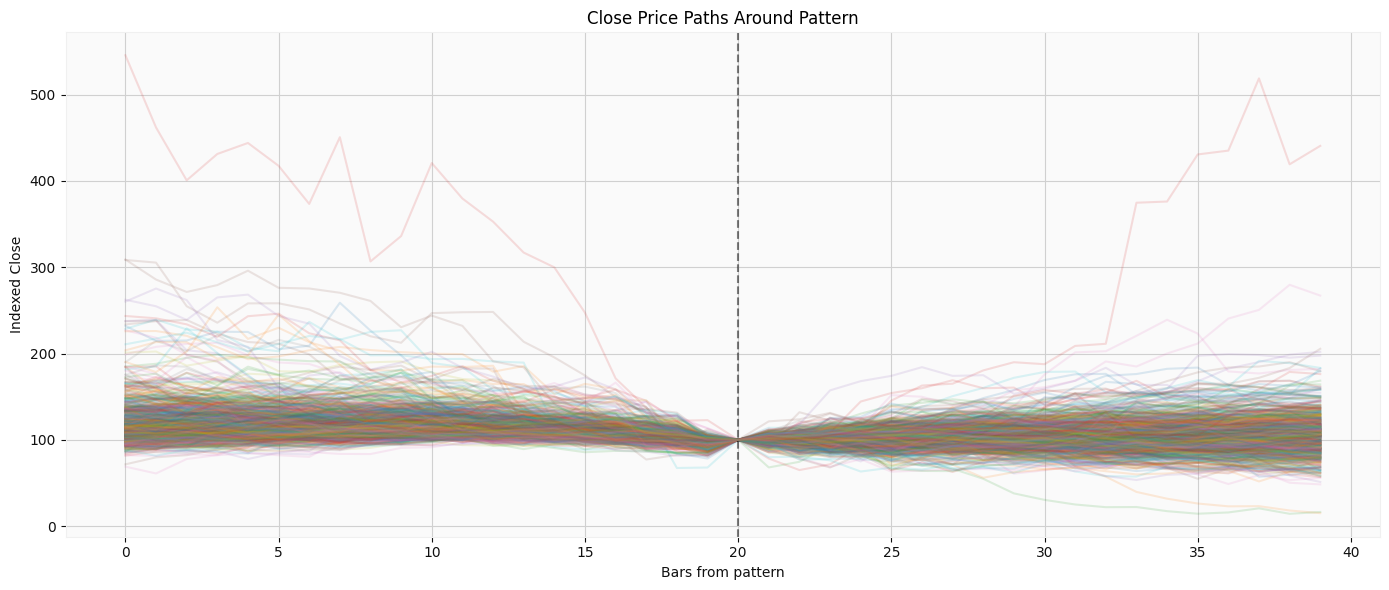

In [749]:
plot_close_overlay_around_patterns(patterns_df)